<img src="https://wereldreizigers.nl/wp-content/uploads/2020/10/airbnb-3399753-scaled.jpg" width="600">


# Bangkok AirBnB Data Analysis
*By: Muhammad Ilman Mughni*

## Business Understanding

Airbnb adalah platform marketplace digital yang menghubungkan:
- Host (pemilik properti) --> menyewakan tempat (rumah, apartemen, kamar, dll)
- Guest (penyewa/traveler) --> mencari akomodasi jangka pendek

Karakteristik Airbnb:
1. Listing dibuat oleh host (judul, deskripsi, foto, harga)
2. Airbnb merupakan Trust-based platform di mana review & rating dari user sangat berpengaruh. Sehingga faktor "Trust" menjadi driver utama conversion
3. Harga dinamis, bergantung kepada musim, demand, event, ataupun lokasi

## Stakeholders
1. **Internal Airbnb** <br>
Tujuan --> optimasi platform & revenue.
    - Product team → meningkatkan algoritma search & ranking listing
    - Pricing team → menentukan strategi harga (dynamic pricing)
    - Growth/Marketing → menarik lebih banyak user & host
    - Data team → membuat model prediksi (occupancy, demand)
1. **Host (Pemilik Properti)** <br>
Tujuan --> meningkatkan profit & okupansi untuk host dan property manager. <br>
Insight untuk host:
    - Zona mana paling profitable
    - Harga optimal (berdasarkan price_capped)
    - Apakah dekat BTS benar-benar meningkatkan booking
1. **Guest/Customer (Traveler/Tourist/Digital Nomads)** <br>
Tujuan --> mendapatkan value listing terbaik dari sisi:
    - Lokasi
    - Price
    - Akses transportasi (BTS)
    - Popularitas (reviews)
1. **Investor & Real Estate Developer** <br>
Tujuan --> menentukan lokasi investasi dengan: 
    - Zona dengan occupancy tinggi
    - Area undervalued (murah tapi demand tinggi)

## Business Problems

Data set ini merupakan kumpulan listing Airbnb di Bangkok dengan review dari 15/12/2012 hingga 28/12/2022. Performa listing bisa dilihat dari beberapa faktor seperti harga, jarak listing ke BTS/pusat sistem transit, jarak listing ke pusat wisata, berapa banyak review, review per bulan, etc. Dari faktor-faktor yang ada, stakeholder ingin melihat ***"Bagaimana faktor spatial (jarak ke pusat kota, akses ke transportasi umum, dan destinasi wisata) dan lokasi mempengaruhi performa listing?"***.

Untuk mengetahui bagaimana faktor spatial dan lokasi mempengaruhi performa listing, berikut merupakan pendekatan analitis yang akan dilakukan:
1. Analisis performa listing berdasarkan zona jarak ke pusat kota
1. Analisis performa listing berdasarkan akses ke BTS (Bangkok Transit System)
1. Analisis performa listing berdasarkan zona jarak ke destinasi wisata dan bandara
1. Analisis korelasi - Spatial vs Performa
    - Bagaimana jarak listing ke landmarks mempengaruhi performa listing (harga, review/month, availability, etc)

## Expected Outcomes

1. *Identifikasi Faktor Spatial Paling Berpengaruh* <br>
Mengetahui faktor mana yang paling mempengaruhi:
    - harga listing
    - demand (reviews per month)
    - tingkat okupansi (occupancy rate)
1. *Insight Pola Hubungan Jarak vs Performa* <br>
Analisis akan menghasilkan pemahaman:
    - Apakah semakin dekat → performa meningkat?
    - Apakah hubungan linear atau non-linear?
    - Apakah ada threshold jarak tertentu?
1. *Pemetaan segment pasar berbasis lokasi*
1. *Evaluasi Dampak Akses Transportasi (BTS)* <br>
Seberapa besar pengaruh akses ke BTS terhadap:
    - harga
    - demand
    - okupansi
1. *Zona Optimal untuk Pricing Strategy*

## Data Dictionary

- `id`: Airbnb's unique identifier for the listing.
- `name`: Name of the listing.
- `host_id`: Airbnb's unique identifier for the host/user.
- `host_name`: Name of the host. Usually, just the first name(s).
- `neighborhood`: The neighborhood is geocoded using the latitude and longitude
- `longitude`: against neighborhoods as defined by open or public digital shapefiles.
- `latitude`: Uses the World Geodetic System (WGS84) projection for latitude and longitude.
- `longitude`: Uses the World Geodetic System (WGS84) projection for latitude and longitude
- `room_type`: [Entire home/apt |Private room| Shared room| Hotel]
    - All homes are grouped into the following three room types:
        1. *Entire place*
            - Entire places are best if you're seeking a home away from
            home. With an entire place, you'll have the whole space to
            yourself. This usually includes a bedroom, a bathroom, a
            kitchen, and a separate, dedicated entrance. Hosts should
            note in the description if they'll be on the property or not (ex:
            "Host occupies the first floor of the home") and provide further
            details on the listing.
        1. *Private rooms*
            - Private rooms are great for when you prefer a little privacy,
            and still value a local connection. When you book a private
            room, you'll have your private room for sleeping and may
            share some spaces with others. You might need to walk
            through indoor spaces that another host or guest may occupy
            to get to your room.
        1. *Shared rooms*
            - Shared rooms are for when you don't mind sharing a space
            with others. When you book a shared room, you'll be sleeping
            in a space that is shared with others and share the entire
            space with other people. Shared rooms are popular among
            flexible travelers looking for new friends and budget-friendly
            stays.
- `price`: Daily price in local currency. Note, the $ sign may be used
despite the locale.
- `minimum_nights`: The minimum number of night stays for the listing (calendar
rules may differ).
- `number_of_reviews`: The number of reviews the listing has.
- `last_review`: The date of the last/newest review.
- `calculated_host_listings_count`: The number of listings the host has in the current scrape in
the city/region geography.
- `availability_365`: The calendar determines the availability of the
listing x days in the future. Note a listing may be available
because it has been booked by a guest or blocked by the
host.
-  `number_of_reviews_ltm`: The number of reviews the listing has in the last 12 months (cumulative).

In [ ]:
# Modul manipulasi data
import pandas as pd
import numpy as np

# Modul visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import folium

## 1. Import/Loading Dataset

In [2]:
df = pd.read_csv("Airbnb Listings Bangkok.csv", parse_dates=['last_review'])
display(df.head(), df.tail())

,Unnamed: 0,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.50,2,353,0
1,1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaT,NaN,2,358,0
2,2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,60,0,NaT,NaN,1,365,0
3,3,35780,Spacious one bedroom at The Kris Condo Bldg. 3,153730,Sirilak,Din Daeng,13.78823,100.57256,Private room,1286,7,2,2022-04-01,0.03,1,323,1
4,4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.76872,100.63338,Private room,1905,1,0,NaT,NaN,3,365,0


,Unnamed: 0,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
15849,15849,790465040741092826,素坤逸核心两房公寓42楼，靠近BTSon nut/无边天际泳池观赏曼谷夜景/出门当地美食街,94899359,Renee,Pra Wet,13.715132,100.653458,Private room,2298,28,0,NaT,NaN,1,362,0
15850,15850,790474503157243541,Euro LuxuryHotel PratunamMKt TripleBdNrShoping...,491526222,Phakhamon,Ratchathewi,13.753052,100.538738,Private room,1429,1,0,NaT,NaN,14,365,0
15851,15851,790475335086864240,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753169,100.538700,Private room,1214,1,0,NaT,NaN,14,365,0
15852,15852,790475546213717328,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754789,100.538757,Private room,1214,1,0,NaT,NaN,14,365,0
15853,15853,790476492384199044,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.752960,100.540820,Private room,1214,1,0,NaT,NaN,14,365,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15854 entries, 0 to 15853
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Unnamed: 0                      15854 non-null  int64         
 1   id                              15854 non-null  int64         
 2   name                            15846 non-null  object        
 3   host_id                         15854 non-null  int64         
 4   host_name                       15853 non-null  object        
 5   neighbourhood                   15854 non-null  object        
 6   latitude                        15854 non-null  float64       
 7   longitude                       15854 non-null  float64       
 8   room_type                       15854 non-null  object        
 9   price                           15854 non-null  int64         
 10  minimum_nights                  15854 non-null  int64         
 11  nu

In [4]:
df.sort_values(by='last_review', ascending=True)

,Unnamed: 0,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
133,133,691478,Studio ๏ Affordable comfort,3533863,Sarasinee,Phaya Thai,13.788870,100.560090,Entire home/apt,500,30,4,2012-12-15,0.03,1,365,0
235,235,936765,Spacious 1 bed apartment close to BTS.,4785506,Ian,Phra Khanong,13.684690,100.607190,Entire home/apt,1290,30,2,2013-04-17,0.02,1,87,0
96,96,430706,7. Bangkok big bright Apartment 402,2129668,Wimonpak,Bang Kho laen,13.700860,100.522760,Entire home/apt,1211,365,8,2013-06-28,0.07,41,365,0
99,99,1138679,1 Bed Pool Access Onnut BTS,4877320,Nisa,Suanluang,13.711190,100.633340,Entire home/apt,970,21,1,2013-07-01,0.01,2,272,0
153,153,742497,Chao Phraya Rumors,3837874,Fr,Samphanthawong,13.739890,100.501790,Private room,1732,5,1,2013-08-18,0.01,1,365,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15849,15849,790465040741092826,素坤逸核心两房公寓42楼，靠近BTSon nut/无边天际泳池观赏曼谷夜景/出门当地美食街,94899359,Renee,Pra Wet,13.715132,100.653458,Private room,2298,28,0,NaT,NaN,1,362,0
15850,15850,790474503157243541,Euro LuxuryHotel PratunamMKt TripleBdNrShoping...,491526222,Phakhamon,Ratchathewi,13.753052,100.538738,Private room,1429,1,0,NaT,NaN,14,365,0
15851,15851,790475335086864240,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753169,100.538700,Private room,1214,1,0,NaT,NaN,14,365,0
15852,15852,790475546213717328,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754789,100.538757,Private room,1214,1,0,NaT,NaN,14,365,0


In [5]:
pd.set_option('display.max_colwidth', 2)
unique_value = []
for col in df.columns:
    unique_value.append([col, df[col].nunique(), df[col].unique()])
    
tabledesc = pd.DataFrame(columns=['Column', 'Number of Unique Value', "Unique Value"], data=unique_value)
tabledesc

,Column,Number of Unique Value,Unique Value
0,Unnamed: 0,15854,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]"
1,id,15854,"[27934, 27979, 28745, 35780, 941865, 1704776, 48736, 1738669, 1744248, 952677, 55681, 1765918, 55686, 59221, 959254, 62217, 1791481, 66046, 105042, 1793000, 960858, 113744, 965722, 1808600, 118118, 1816517, 969792, 121410, 145343, 973830, 156583, 1823321, 159854, 976690, 978531, 166267, 169285, 978969, 1842066, 169514, 1849029, 1862089, 985743, 988373, 172332, 1016487, 1862331, 1862377, 185364, 1887544, 1888303, 1019241, 241416, 1026451, 1028469, 1028486, 1035589, 1035640, 1897982, 296960, 1898332, 1041976, 313459, 1052180, 1926489, 320014, 1933894, 1057173, 1060320, 384924, 1067748, 1077493, 1943048, 385130, 385278, 385979, 390611, 1947314, 1079039, 1086843, 393066, 397449, 405662, 1088343, 1094136, 1961981, 407381, 1975849, 1133843, 413824, 428360, 428421, 428907, 428950, 430691, 430703, 430706, 432004, 439051, 1138679, ...]"
2,name,14794,"[Nice room with superb city view, Easy going landlord,easy place, modern-style apartment in Bangkok, Spacious one bedroom at The Kris Condo Bldg. 3, Suite Room 3 at MetroPoint, NEw Pro!! Bungalow Bkk Centre, Condo with Chaopraya River View, 1 chic bedroom apartment in BKK, Batcave, Pool view, near Chatuchak, Standard Room Decor do Hostel, Sathorn Terrace Apartment(61), 2BR apt in a cozy neighborhood, Comfy bedroom near River pier & BTS Taksin., budget hotel bangkok near subway, Deluxe Condo, Nana, Pool/GYM/Sauna, Luxury@swimpool/FreeWiFi/nearJJMkt, Nice and Quiet condo near BTS Onnut, 24Flr- 1br Apt near JJ, MRT, BTS, Central Bangkok 3 Bedroom Apartment, The Duplex - Asoke- Luxury 92sqm, New, Stylish & Luxury Studio Condo, River View - Ivy Condo (1 Bedroom), Siamese Gioia on Sukhumvit 31, Contemporary Modern Duplex-Thong Lo, Pan Dao Condo 5 min from BTS On Nut, 1 BR condominium center BKK +NETFLIX+55SQM, 1 penthouse in central Bangkok, MetroPoint Suite Room, Near Airport, Boutique Rooms Near Bangkok Airport, BangLuang House1 @ Bangkok Thailand, Studio near Chula University/Silom walk to MRT/BTS, กรองทองแมนชั่น (ลาดพร้าว 81), Deluxe one Bedroom Condo w.Pool-GYM & Sauna 8-7, Beautiful 1 BR apartment @BTS Ari, Urban Oasis in the heart of Bangkok, 1Bed apt. near Chula University/Silom, Stay at the ROARING RATCHADA!, 60 m2 apartment in Thong Lor, Bangkok, ICONSIAM River view on 49th floor, 2br apt in Sukhumvit Asoke near BTS, Self catering cozy1-bed near BTS, ❂☀☀☀Perfect Escape☀☀☀Sunny Roof EnSuite☀☀☀☀, Room with city view of BKK, BangLuang House 2@ Bangkok Thailand, Tranquility found in busy Bangkok near new skytran, Private room in Bangkok, ☞✪✪✪✪Roomy Studio 4 Family r friends✪No Stairs✪✪✪✪, ☞Downtown Central Studio-Bangkok MRT, Beautiful Wood Bangkok Resort House, ""Serviced 2 Bed Scenic SkyVillas"", Cozy 1BR rooftop (BTS Ploenchit) heart of bangkok, Chic two bedroom for Monthly rental, Sukhumvit52 near SkyTrain to BkkCBD, ♡Chic Studio, Easy Walk to Pier & BTS Taksin♡, One Bedroom Suite- WIFI- SATHORN, STUDIO RM2 - WIFI- SATHORN, Quiet Double Bed Apartment, Quiet Double Bed Apartment, Suvarnabhumi free transfer, Luxury&Comfy wthWifi walk-distance to Subwy-Malls, Apr. for rent full fur 1 bedroom, monthly, Long-stay special rate spacious entire floor Siam, One Bed Room at Sukumvit 50 Bangkok, City View, relaxed theme & delicious food around, Ideo Blucove Sukhumvit Bangkok, 2-BR condo near BTS on Sukhumvit Rd, NewlyRenovated! 3Br,SingleHouse, Park/BTS/Airport., IdeoMix, Sukhumvit RD, close to BTS, Mix Dorm Decor do Hostel, Oasis in the heart of Bangkok, 5 mins by car from Chong Nonsi BTS Station, Inn Saladaeng - Superior hotel roo

## 2. Data Cleaning

### *Missing Values Handling*

#### Drop kolom 'Unnamed: 0' karena tidak digunakan untuk analisis dataset

In [6]:
df_clean = df.copy()
df_clean.head()

,Unnamed: 0,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.50,2,353,0
1,1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaT,NaN,2,358,0
2,2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,60,0,NaT,NaN,1,365,0
3,3,35780,Spacious one bedroom at The Kris Condo Bldg. 3,153730,Sirilak,Din Daeng,13.78823,100.57256,Private room,1286,7,2,2022-04-01,0.03,1,323,1
4,4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.76872,100.63338,Private room,1905,1,0,NaT,NaN,3,365,0


In [7]:
df_clean.drop(columns='Unnamed: 0', inplace=True)
df_clean.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.50,2,353,0
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaT,NaN,2,358,0
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,60,0,NaT,NaN,1,365,0
3,35780,Spacious one bedroom at The Kris Condo Bldg. 3,153730,Sirilak,Din Daeng,13.78823,100.57256,Private room,1286,7,2,2022-04-01,0.03,1,323,1
4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.76872,100.63338,Private room,1905,1,0,NaT,NaN,3,365,0


#### Melihat jumlah dan persentase missing value pada dataset

In [8]:
mv = df_clean.isnull().sum()
mv_pctg = round((df_clean.isnull().sum())/df_clean.shape[0]*100,2)
mv_report = pd.DataFrame({"Missing Value":mv, "%":mv_pctg})

print("Total missing values on dataset:")
display(mv_report)

Total missing values on dataset:


,Missing Value,%
id,0,0.00
name,8,0.05
host_id,0,0.00
host_name,1,0.01
neighbourhood,0,0.00
latitude,0,0.00
longitude,0,0.00
room_type,0,0.00
price,0,0.00
minimum_nights,0,0.00


#### Handle missing value pada kolom 'name' dan 'host_name'

Karena proporsi missing value pada kolom 'name' dan 'host_name' sangat kecil (<1%), maka kita bisa drop baris di mana terdapat kolom kosong pada kedua kolom tersebut


In [9]:
df_clean[df_clean['name'].isna() | df_clean['host_name'].isna()]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
439,4549768,NaN,18852579,Titawan,Phra Khanong,13.69406,100.59619,Private room,1080,5,0,NaT,NaN,1,365,0
544,4720818,NaN,24386225,Cherry,Din Daeng,13.77562,100.57346,Private room,1200,1,0,NaT,NaN,1,365,0
572,4245018,NaN,22030043,Parichart,Bang Phlat,13.78376,100.49821,Private room,1200,1,0,NaT,NaN,1,365,0
669,6148415,NaN,31895202,Chira,Bang Na,13.68276,100.60894,Entire home/apt,2424,2,0,NaT,NaN,1,365,0
1030,8055144,NaN,42521288,Nantida,Vadhana,13.74126,100.55761,Private room,5000,3,0,NaT,NaN,1,365,0
1282,10000742,NaN,51374914,Diamond Bangkok,Ratchathewi,13.75328,100.52928,Private room,930,1,6,2017-05-13,0.07,1,365,0
1594,10710165,NaN,55347997,Khaneungnit,Vadhana,13.71757,100.60464,Private room,1000,1,0,NaT,NaN,1,365,0
2075,13142743,NaN,73275200,Pakaphol,Khlong Toei,13.72566,100.56416,Private room,850,1,2,2017-12-11,0.03,3,220,0
3571,19682464,Cozy Hideaway,137488762,NaN,Bang Kapi,13.76999,100.63769,Private room,1399,3,1,2017-07-29,0.02,1,365,0


In [10]:
df_clean = df_clean.dropna(subset=['name', 'host_name'])

mv = df_clean.isnull().sum()
mv_pctg = round((df_clean.isnull().sum())/df_clean.shape[0]*100,2)
mv_report = pd.DataFrame({"Missing Value":mv, "%":mv_pctg})

print("Total missing values on dataset:")
display(mv_report)

Total missing values on dataset:


,Missing Value,%
id,0,0.0
name,0,0.0
host_id,0,0.0
host_name,0,0.0
neighbourhood,0,0.0
latitude,0,0.0
longitude,0,0.0
room_type,0,0.0
price,0,0.0
minimum_nights,0,0.0


Kolom 'name' dan 'host_name' masuk ke dalam kategori Missing Completely at Random (MCAR), karena:
1. Hanya 8 (untuk 'name') dan 1 (untuk 'host_name') missing value dari 15,000 data
1. Tidak ada pola tertentu (*completely random*)
1. Tidak ada hubungan dengan variabel lain

#### Handle missing value pada kolom 'last_review' dan 'reviews_per_month'

In [11]:
df_clean[df_clean['last_review'].isna() | df_clean['reviews_per_month'].isna()][['last_review', 'reviews_per_month', 'number_of_reviews']]
df_missing = df_clean[df_clean['last_review'].isna() | df_clean['reviews_per_month'].isna()].copy()
display(df_clean[df_clean['last_review'].isna() | df_clean['reviews_per_month'].isna()][['last_review', 'reviews_per_month', 'number_of_reviews']])
display(df_missing)

,last_review,reviews_per_month,number_of_reviews
1,NaT,NaN,0
2,NaT,NaN,0
4,NaT,NaN,0
7,NaT,NaN,0
14,NaT,NaN,0
...,...,...,...
15849,NaT,NaN,0
15850,NaT,NaN,0
15851,NaT,NaN,0
15852,NaT,NaN,0


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.668180,100.616740,Private room,1316,1,0,NaT,NaN,2,358,0
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.752320,100.624020,Private room,800,60,0,NaT,NaN,1,365,0
4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.768720,100.633380,Private room,1905,1,0,NaT,NaN,3,365,0
7,1738669,1 chic bedroom apartment in BKK,7045870,Jiraporn,Chatu Chak,13.829250,100.567370,Entire home/apt,1461,1,0,NaT,NaN,1,365,0
14,959254,"Deluxe Condo, Nana, Pool/GYM/Sauna",5153476,Natcha,Khlong Toei,13.715160,100.568060,Entire home/apt,1400,30,0,NaT,NaN,1,365,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15849,790465040741092826,素坤逸核心两房公寓42楼，靠近BTSon nut/无边天际泳池观赏曼谷夜景/出门当地美食街,94899359,Renee,Pra Wet,13.715132,100.653458,Private room,2298,28,0,NaT,NaN,1,362,0
15850,790474503157243541,Euro LuxuryHotel PratunamMKt TripleBdNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753052,100.538738,Private room,1429,1,0,NaT,NaN,14,365,0
15851,790475335086864240,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753169,100.538700,Private room,1214,1,0,NaT,NaN,14,365,0
15852,790475546213717328,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754789,100.538757,Private room,1214,1,0,NaT,NaN,14,365,0


#### Kesimpulan missing value kolom 'last_review' dan 'reviews_per_month'
1. Kedua kolom 'last_review' dan 'reviews_per_month' memiliki jumlah missing value yang sama yaitu 5790 data (~36%)
1. Untuk setiap 'last_review' yang bernilai NaT, 'number_of_review' sudah pasti bernilai 0. Mengapa demikian? Interpretasinya adalah sebagai berikut:
    - listing tidak pernah mendapat review
    - listing tidak perform
    - listing baru
    - akan dibiarkan NaT
1. Untuk setiap 'reviews_per_month' yang bernilai NaN, 'number_of_reviews' pasti juga bernilai 0. Interpretasinya adalah sebagai berikut:
    - tidak ada aktivitas review untuk listing terkait
    - akan diisi 0
1. Untuk Listing yang tidak ada review dari customer, bukan berarti data tersebut *error*, melainkan bisa terjadi karena beberapa hal seperti yang sudah disebutkan di atas
    - Secara logika: tidak ada review --> 0 review per bulan

<br>

*Rekomendasi dataset missing value (df_missing)*
1. Berikan badge "new listing" untuk listing baru
1. Berikan exposure lebih untuk listing yang tidak pernah mendapat review
1. Perlu mengedukasi host terkait:
    - strategi pricing
    - optimasi listing

#### Missing value pada kolom 'reviews_per_month' diisi dengan 0

In [12]:
df_clean['reviews_per_month'].fillna(0, inplace=True)

#### Missing value pada kolom 'last_review' dibiarkan NaT dan akan dibuat kolom baru 'has_review' untuk listing yang memiliki review

In [13]:
df_clean['has_review'] = df_clean['last_review'].notna().astype(int)

'has_review' akan memiliki 2 kelompok nilai:
- 1 = listing pernah mendapat review
- 0 = belum pernah mendapat review

In [14]:
mv = df_clean.isnull().sum()
mv_pctg = round((df_clean.isnull().sum())/df_clean.shape[0]*100,2)
mv_report = pd.DataFrame({"Missing Value":mv, "%":mv_pctg})

print("Total missing values on dataset:")
display(mv_report)

Total missing values on dataset:


,Missing Value,%
id,0,0.0
name,0,0.0
host_id,0,0.0
host_name,0,0.0
neighbourhood,0,0.0
latitude,0,0.0
longitude,0,0.0
room_type,0,0.0
price,0,0.0
minimum_nights,0,0.0


#### Dataset sudah bersih dari missing value kecuali kolom 'last_review'. Karena NaT di 'last_review' bukan *error* melainkan **belum pernah direview** sehingga NaT di situ memiliki interpretasi bisnis

In [15]:
display(df_clean.describe(include='number'))
display(df_clean.describe(include='object'))

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review
count,1.584500e+04,1.584500e+04,15845.000000,15845.000000,1.584500e+04,15845.000000,15845.000000,15845.000000,15845.000000,15845.000000,15845.000000,15845.000000
mean,1.580294e+17,1.541645e+08,13.745148,100.559895,3.218580e+03,15.299905,16.663048,0.516464,13.896813,244.319281,3.483496,0.634964
std,2.946611e+17,1.318845e+08,0.043044,0.050915,2.497917e+04,50.828453,40.623125,0.952948,30.276935,125.849614,8.919083,0.481456
min,2.793400e+04,5.892000e+04,13.527300,100.329550,0.000000e+00,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.104514e+07,3.974431e+07,13.720090,100.529690,9.000000e+02,1.000000,0.000000,0.000000,1.000000,138.000000,0.000000,0.000000
50%,3.505717e+07,1.224556e+08,13.738490,100.561400,1.429000e+03,1.000000,2.000000,0.090000,4.000000,309.000000,0.000000,1.000000
75%,5.258780e+07,2.392258e+08,13.759490,100.585140,2.429000e+03,7.000000,13.000000,0.670000,13.000000,360.000000,3.000000,1.000000
max,7.908162e+17,4.926659e+08,13.953540,100.923440,1.100000e+06,1125.000000,1224.000000,19.130000,228.000000,365.000000,325.000000,1.000000


,name,host_name,neighbourhood,room_type
count,15845,15845,15845,15845
unique,14793,5306,50,4
top,New! La Chada Night Market studio 2PPL near MRT,Curry,Vadhana,Entire home/apt
freq,45,228,2151,8911


### *Duplicated Data Handling*

In [16]:
# Cek baris yang terduplikat
df_clean[df_clean.duplicated(keep=False)]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review


***Tidak ada data duplikat pada dataset ini***

In [17]:
dup_summary = pd.DataFrame({
    'column': df_clean.columns,
    'duplicate_count': [df_clean[col].duplicated().sum() for col in df_clean.columns],
    'unique_count': [df_clean[col].nunique() for col in df_clean.columns]
})

dup_summary.sort_values(by='duplicate_count', ascending=False)
dup_summary['duplicate_ratio'] = dup_summary['duplicate_count'] / len(df_clean)
dup_summary.sort_values(by='duplicate_ratio', ascending=False)

,column,duplicate_count,unique_count,duplicate_ratio
16,has_review,15843,2,0.999874
7,room_type,15841,4,0.999748
13,calculated_host_listings_count,15795,50,0.996844
4,neighbourhood,15795,50,0.996844
15,number_of_reviews_ltm,15760,85,0.994636
9,minimum_nights,15759,86,0.994572
10,number_of_reviews,15547,298,0.981193
14,availability_365,15479,366,0.976901
12,reviews_per_month,15331,514,0.967561
11,last_review,14176,1668,0.894667


**Kesimpulan duplicated data:**
1. Hasil di atas menunjukkan hasil yang normal
1. Duplicated ratio yang tinggi pada sebagian besar kolom menunjukkan bahwa dataset didominasi oleh fitur dengan variabilitas rendah (*low cardinality*) dan bukan merupakan indikasi masalah
1. Semakin sedikit jumlah elemen unik maka semakin besar duplicated count

In [18]:
for col in df_clean.columns:
    print(f"\n=== Kolom: {col} ===")
    
    dup_values = df_clean[col].value_counts()
    dup_values = dup_values[dup_values > 1]
    
    print(dup_values.head(10))


=== Kolom: id ===
Series([], Name: count, dtype: int64)

=== Kolom: name ===
name
New!  La Chada Night Market studio 2PPL near MRT      45
30days! AirportLink Sukhumvit NANA MaxValu 2BR(4P)    35
New!  La Chada Night Market 1BR 2PPL near MRT         35
New! Gateway/ Bangkok University 1BR 2PPL near BTS    29
30days!  Sukhumvit NANA spacious 1BR 2PPL near BTS    25
1BR Twin Suit 2ppl/Surasak BTS Sathorn/Pool /WIFI     24
1BR Twin Suit 2ppl/Surasak BTS Sathorn/Pool /Wifi     21
Near The Grand Palace/ASOK Station/Sukhumvit          18
2BR！New! Near The Grand Palace/ASOK Station/4PPL      15
Nana BTS Spacious 1BR W/Balcony Asok Terminal 21      14
Name: count, dtype: int64

=== Kolom: host_id ===
host_id
201677068    228
52161947     99 
26736483     89 
68154488     62 
228535635    62 
62257044     56 
8444643      53 
312545246    49 
314945555    49 
66923696     48 
Name: count, dtype: int64

=== Kolom: host_name ===
host_name
Curry       228
Noons       99 
K           91 
Pornchai 

**Interpretasi duplicated data berdasarkan kategori kardinalitas:**
1. Low Cardinality (Duplikat tinggi = NORMAL) <br>
    Kolom seperti `has_review`, `room_type`, `neighbourhood`, `minimum_nights` memiliki elemen unik yang sedikit (<100)
    - `room_type` memiliki 4 elemen unik --> menunjukkan bahwa market tidak terlalu variatif
    - `neighbourhood` memiliki 50 elemen unik --> menunjukkan bahwa area distribusi listing terbatas
1. Semi Cardinality <br>
    Kolom seperti `host_name`, `host_id`, `calculated_host_listings_count` termasuk ke dalam semi-cardinality karena elemen uniknya yang lumayan bervariasi
    - `host_id` --> 1 host bisa memiliki banyak listing
    - `calculated_host_listings_count` --> banyak host dengan jumlah listing yang sama
    - Insight --> multi-property host (listing dimiliki oleh perseroan/bisnis, bukan individu)
1. Numerical Columns Behaviour <br>
    Termasuk kolom `number_of_reviews`, `reviews_per_month`, `availability_365`, `number_of_reviews_ltm`
    - Nilai duplikat tinggi karena nilai diskrit dan banyak angka berulang
    - Insight --> banyak listing dengan performa mirip, market cukup homogen
1. Kolom penting untuk insight <br>
    Termasuk kolom `price` dan `last_review`
    - Pricing cukup variatif
    - Aktivitas listing beragam (`last_review`)
1. Kolom lokasi `latitude` dan `longitude`
    - Terdapat duplikat pada kolom tersebut merupakan hal yang wajar karena beberapa listing berada di lokasi yang sama (apartemen, gedung, etc)

#### *Analisis data duplikat `latitude` dan `longitude`*

In [19]:
dup_latlong = df_clean.groupby(['latitude', 'longitude']).size().reset_index(name='count')

# ambil yang duplikat (count > 1)
dup_latlong = dup_latlong[dup_latlong['count'] > 1].sort_values(by='count', ascending=False)

dup_latlong

,latitude,longitude,count
2288,13.710777,100.519891,21
3977,13.720620,100.547070,13
10518,13.754188,100.563269,13
10271,13.752840,100.531240,12
11550,13.760440,100.569440,12
...,...,...,...
14509,13.828505,100.527433,2
14740,13.841590,100.559780,2
14993,13.889170,100.592210,2
15123,13.913359,100.589626,2


In [20]:
top3_coords = dup_latlong.head(3)
top3_coords

,latitude,longitude,count
2288,13.710777,100.519891,21
3977,13.720620,100.547070,13
10518,13.754188,100.563269,13


In [21]:
top3_listings = df_clean.merge(
    top3_coords[['latitude', 'longitude']],
    on=['latitude', 'longitude']
)

cols = [
    'name', 'host_id', 'host_name',
    'neighbourhood', 'room_type',
    'price', 'minimum_nights',
    'number_of_reviews', 'reviews_per_month',
    'availability_365',
    'latitude', 'longitude'
]

top3_listings[cols].sort_values(
    by=['latitude', 'longitude', 'host_id']
).head(50)

,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,latitude,longitude
28,沙吞老城区精品loft/唐人街/Silom/摩天轮夜市,20133201,Willam,Sathon,Entire home/apt,1580,1,0,0.00,339,13.710777,100.519891
36,Sathon Luxury 2 br/China Town/Icon Siam,20133201,Willam,Sathon,Entire home/apt,2221,1,1,0.91,340,13.710777,100.519891
37,Sathon Luxury 2 br/China Town/Icon Siam,20133201,Willam,Sathon,Entire home/apt,2221,1,0,0.00,340,13.710777,100.519891
38,沙吞花园式精品两居居室/摩天轮河边夜市/唐人街/icomsiam,20133201,Willam,Sathon,Entire home/apt,2221,1,0,0.00,340,13.710777,100.519891
14,1BR Twin Suit 2ppl/Surasak BTS Sathorn/Pool /WIFI,52161947,Noons,Sathon,Entire home/apt,1244,1,0,0.00,360,13.710777,100.519891
42,"曼谷市中心高端公寓/近BTS/游泳池/健身房,近BTS,免费高速WIFI,帕蓬夜市14分钟可达",219984842,TTzahome,Sathon,Entire home/apt,1184,1,0,0.00,354,13.710777,100.519891
43,"曼谷市中心loft公寓/近BTS/游泳池/健身房,近BTS,免费高速WIFI,帕蓬夜市14分钟可达",219984842,TTzahome,Sathon,Entire home/apt,1333,1,0,0.00,350,13.710777,100.519891
44,"曼谷市中心loft公寓/近BTS/游泳池/健身房,近BTS,免费高速WIFI,帕蓬夜市14分钟可达",219984842,TTzahome,Sathon,Entire home/apt,1285,1,0,0.00,342,13.710777,100.519891
21,曼谷市中心loft公寓/近BTS，毗邻曼谷河滨！美食街 帕蓬夜市14分钟可达/WIFI/游泳池免费,227771817,MeetU,Sathon,Entire home/apt,1370,1,0,0.00,341,13.710777,100.519891
22,曼谷市中心loft公寓/近BTS，毗邻曼谷河滨！美食街 帕蓬夜市14分钟可达/WIFI/游泳池免费,227771817,MeetU,Sathon,Entire home/apt,1276,1,1,1.00,342,13.710777,100.519891


Melalui pengecekan secara random sampling dari 3 koordinat dengan frekuensi kemunculan terbanyak, **terdapat data duplikat** pada dataset ini. <br>
Metode sebelumnya tidak bisa mendeteksi adanya data duplikat karena terdapat perbedaan nilai di kolom 'id' walaupun nilai pada kolom lain sama persis.

Definisi listing yang terduplikat adalah listing yang kolom 'name', 'host_name', 'host_id', 'room_type', 'price', 'latitude', dan 'longitude' memiliki value yang sama

In [22]:
duplicates = df_clean[df_clean.duplicated(
    subset=['name', 'host_id', 'host_name', 'neighbourhood', 'price', 'latitude', 'longitude'],
    keep=False
)]

duplicates

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review
486,4639962,"Sukhumvit, 5 min walk to Sky Train Asoke Station",24021888,Maitria Hotel Sukhumvit 18,Khlong Toei,13.733130,100.562590,Private room,4871,1,27,2022-07-11,0.28,12,364,1,1
1162,7717620,"Sukhumvit, 5 min walk to Sky Train Asoke Station",24021888,Maitria Hotel Sukhumvit 18,Khlong Toei,13.733130,100.562590,Private room,4871,1,20,2019-08-08,0.30,12,364,0,1
2119,13777582,"Studio with Zen garden view (30sqm), LUXX Silom",68154488,Dusadee,Bang Rak,13.726330,100.525310,Hotel room,1777,1,1,2017-03-18,0.01,62,271,0,1
3119,18029609,"Studio,5min walk Skytrain Asoke,WiFi,Terminal21",24021888,Maitria Hotel Sukhumvit 18,Khlong Toei,13.733130,100.562590,Private room,4871,1,3,2017-12-16,0.05,12,364,0,1
3329,18396802,Studio for 2PAX: 1-Min from BTS Nana,3773805,Danai And BicGy,Khlong Toei,13.739370,100.555210,Entire home/apt,2470,2,63,2022-01-14,0.93,13,325,1,1
3473,19000129,Studio for 2PAX: 1-Min from BTS Nana,3773805,Danai And BicGy,Khlong Toei,13.739370,100.555210,Entire home/apt,2470,2,71,2022-12-26,1.06,13,343,18,1
3903,21045066,"Studio with Zen garden view (30sqm), LUXX Silom",68154488,Dusadee,Bang Rak,13.726330,100.525310,Hotel room,1777,1,0,NaT,0.00,62,271,0,0
3968,20806638,"Studio,5min walk Skytrain Asoke,WiFi,Terminal21",24021888,Maitria Hotel Sukhumvit 18,Khlong Toei,13.733130,100.562590,Hotel room,4871,1,8,2018-06-21,0.13,12,364,0,1
5890,28831409,NA BANGLAMPOO GUEST HOUSE,87704107,Yui,Phra Nakhon,13.762790,100.497900,Private room,1400,1,0,NaT,0.00,9,361,0,0
5976,28907857,NA BANGLAMPOO GUEST HOUSE,87704107,Yui,Phra Nakhon,13.762790,100.497900,Private room,1400,1,0,NaT,0.00,9,361,0,0


***Remove data duplikat***

In [23]:
df_clean = df_clean.drop(index=[1162,3329,5890,6529,6548,6554,7463,8217,8790,14015,14116,14147,14401,14429,14663,14679,14940,15120,15183,15186,15190,15191,15195,15549,15614,15829,3903,3119,14021,14174,14388,15137,15220])

duplicates2 = df_clean[df_clean.duplicated(
    subset=['name', 'host_id', 'host_name', 'neighbourhood', 'price', 'latitude', 'longitude'],
    keep=False
)]

duplicates2

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review


***Tidak ada lagi data duplikat yang terdeteksi***

### *Inconsistent Data Handling*

#### *Handling kolom object/kategori*

In [24]:
for col in df_clean.select_dtypes(include="object"):
    print(df_clean[col].value_counts())
    print()

name
New!  La Chada Night Market studio 2PPL near MRT      45
30days! AirportLink Sukhumvit NANA MaxValu 2BR(4P)    35
New!  La Chada Night Market 1BR 2PPL near MRT         35
30days!  Sukhumvit NANA spacious 1BR 2PPL near BTS    25
1BR Twin Suit 2ppl/Surasak BTS Sathorn/Pool /WIFI     24
                                                      ..
Pratunam Platinum near Hostel 1R                      1 
Pratunam Platinum Hostel 2Room                        1 
Pratunam Platinum Hostel 1R D'bl                      1 
Bkk/BTS Surasak/温馨loft公寓5/免费泳池/健身房/WIFI/免费停车          1 
Spacious one bedroom at The Kris Condo Bldg. 3        1 
Name: count, Length: 14793, dtype: int64

host_name
Curry        219
Noons        98 
K            91 
Pornchai     63 
Bee          62 
             .. 
Anya         1  
Parinya      1  
Penjit       1  
Non          1  
Phatchara    1  
Name: count, Length: 5306, dtype: int64

neighbourhood
Vadhana                 2149
Khlong Toei             2087
Huai Khwang     

**Tidak ada data inkonsisten pada kolom kategori/object**

#### *Handling kolom numerik*

#### 1. Check apakah ada nilai negatif dan melebihi batas logis

In [25]:
# contoh untuk semua kolom numerik
num_cols = df_clean.select_dtypes(include='number').columns

for col in num_cols:
    print(f"\n=== {col} ===")
    
    print("Min:", df_clean[col].min())
    print("Max:", df_clean[col].max())
    
    if (df_clean[col] < 0).any():
        print("⚠️ Ada nilai negatif")
    else:
        print("✅ Tidak ada nilai negatif")


=== id ===
Min: 27934
Max: 790816217344482012
✅ Tidak ada nilai negatif

=== host_id ===
Min: 58920
Max: 492665929
✅ Tidak ada nilai negatif

=== latitude ===
Min: 13.5273
Max: 13.95354
✅ Tidak ada nilai negatif

=== longitude ===
Min: 100.32955
Max: 100.92344
✅ Tidak ada nilai negatif

=== price ===
Min: 0
Max: 1100000
✅ Tidak ada nilai negatif

=== minimum_nights ===
Min: 1
Max: 1125
✅ Tidak ada nilai negatif

=== number_of_reviews ===
Min: 0
Max: 1224
✅ Tidak ada nilai negatif

=== reviews_per_month ===
Min: 0.0
Max: 19.13
✅ Tidak ada nilai negatif

=== calculated_host_listings_count ===
Min: 1
Max: 228
✅ Tidak ada nilai negatif

=== availability_365 ===
Min: 0
Max: 365
✅ Tidak ada nilai negatif

=== number_of_reviews_ltm ===
Min: 0
Max: 325
✅ Tidak ada nilai negatif

=== has_review ===
Min: 0
Max: 1
✅ Tidak ada nilai negatif


#### 2. Check outlier pada kolom numerik

In [26]:
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

id: 3549 outliers
host_id: 0 outliers
latitude: 1097 outliers
longitude: 602 outliers
price: 1395 outliers
minimum_nights: 3166 outliers
number_of_reviews: 2239 outliers
reviews_per_month: 1465 outliers
calculated_host_listings_count: 1813 outliers
availability_365: 0 outliers
number_of_reviews_ltm: 2219 outliers
has_review: 0 outliers


##### *Handling kolom `price`*

In [27]:
df_clean[df_clean['price'] == 0]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review
11103,44563108,Somerset Maison Asoke Bangkok,360620448,Somerset Maison Asoke,Vadhana,13.73815,100.5642,Hotel room,0,1,0,NaT,0.0,1,0,0,0


Terdapat 1 listing dengan 'price' == 0 sehingga bisa langsung didrop

In [28]:
df_clean = df_clean[df_clean['price'] > 0]

In [29]:
col = 'minimum_nights'  # contoh

Q1 = df_clean[col].quantile(0.25)
Q3 = df_clean[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].sort_values(by='minimum_nights', ascending=False).head(20)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review
61,1041976,Long-stay special rate spacious entire floor Siam,5735895,Pariya,Parthum Wan,13.74814,100.52016,Entire home/apt,2900,1125,295,2021-08-21,2.61,3,0,0,1
7986,35165443,Wonderful apartment for you holiday in Thai,86991723,Yang,Bang Na,13.67260,100.60352,Entire home/apt,2000,1115,0,NaT,0.00,2,358,0,0
11524,49032568,Freehold Condo near Bangsue Grand Station,4661237,Chayanid,Bang Sue,13.80697,100.52362,Entire home/apt,554,1095,0,NaT,0.00,1,358,0,0
10153,41623113,blossom condo舒适双床房摩天轮夜市周边免费泳池健身房@Sathon surasakBTS,162537040,Songnya,Sathon,13.71195,100.52055,Entire home/apt,650,1000,2,2020-03-08,0.06,13,179,0,1
10644,42685153,The Prime Sukhumvit 11 - Room 29/150,337709866,Vatiaz,Vadhana,13.74426,100.55758,Private room,15143,999,0,NaT,0.00,1,89,0,0
11243,45051929,Bellevue Boutique Bangkok | Airport Link HUA-MAK,165329146,Sataporn,Suanluang,13.73633,100.63836,Private room,1314,999,0,NaT,0.00,2,181,0,0
1200,8801560,"30th floor, 10 min to BTS, Seaview",4517723,Kannicha,Bang Na,13.66417,100.64955,Entire home/apt,35000,998,20,2022-10-30,0.26,7,365,5,1
1592,10709131,"34Fl 2, M Ladprao Condo,MRT & Malls",32398198,Touchapon,Chatu Chak,13.81699,100.56292,Entire home/apt,760,700,61,2019-08-25,0.73,2,364,0,1
3694,19893829,2 Bedroom Suite@Kirthana Residence,64131143,Chetna,Vadhana,13.73917,100.56616,Entire home/apt,7286,500,0,NaT,0.00,3,48,0,0
1833,12046101,Near BTS Onnut Convenience house,22676472,Kuan,Suanluang,13.71161,100.60344,Entire home/apt,1300,500,2,2016-07-30,0.02,3,363,0,1


##### *Handling kolom `minimum_nights`*

In [30]:
df_clean['minimum_nights'].describe()

count    15811.000000
mean     15.326039   
std      50.879038   
min      1.000000    
25%      1.000000    
50%      1.000000    
75%      7.000000    
max      1125.000000 
Name: minimum_nights, dtype: float64

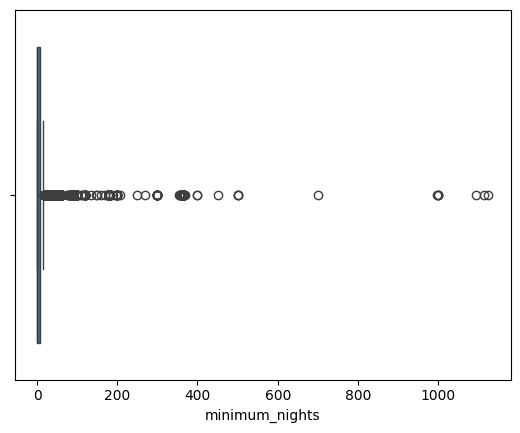

In [31]:
sns.boxplot(x=df_clean['minimum_nights'])
plt.show()

In [32]:
Q1 = df_clean['minimum_nights'].quantile(0.25)
Q3 = df_clean['minimum_nights'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df_clean[(df_clean['minimum_nights'] > upper_bound) | (df_clean['minimum_nights'] < lower_bound)]

# jumlah outlier
n_outliers = outliers.shape[0]

# persentase
pct_outliers = n_outliers / len(df_clean) * 100

print(f"IQR: {IQR}\nJumlah Outlier: {n_outliers}\nPersentase Outlier: {pct_outliers}\nUpper Bound: {upper_bound}\nLower Bound: {lower_bound}")

IQR: 6.0
Jumlah Outlier: 3166
Persentase Outlier: 20.024033900449055
Upper Bound: 16.0
Lower Bound: -8.0


In [33]:
outliers[df_clean.columns].sort_values(by='minimum_nights', ascending=False)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review
61,1041976,Long-stay special rate spacious entire floor Siam,5735895,Pariya,Parthum Wan,13.748140,100.520160,Entire home/apt,2900,1125,295,2021-08-21,2.61,3,0,0,1
7986,35165443,Wonderful apartment for you holiday in Thai,86991723,Yang,Bang Na,13.672600,100.603520,Entire home/apt,2000,1115,0,NaT,0.00,2,358,0,0
11524,49032568,Freehold Condo near Bangsue Grand Station,4661237,Chayanid,Bang Sue,13.806970,100.523620,Entire home/apt,554,1095,0,NaT,0.00,1,358,0,0
10153,41623113,blossom condo舒适双床房摩天轮夜市周边免费泳池健身房@Sathon surasakBTS,162537040,Songnya,Sathon,13.711950,100.520550,Entire home/apt,650,1000,2,2020-03-08,0.06,13,179,0,1
10644,42685153,The Prime Sukhumvit 11 - Room 29/150,337709866,Vatiaz,Vadhana,13.744260,100.557580,Private room,15143,999,0,NaT,0.00,1,89,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14109,719427445071566280,2 bdr 100sqm 6 mn to ASOK BT & Sukhumvit MRT,153572915,Stella,Khlong Toei,13.732313,100.562564,Entire home/apt,3557,18,3,2022-12-04,1.36,2,333,3,1
5979,29379952,New Pool View Condo by MRT HuayKwang,184339795,Atikun,Din Daeng,13.784080,100.572710,Entire home/apt,800,18,19,2022-12-15,0.38,4,138,7,1
11670,50281748,Luxury 1Bed Suite with great Facilities @ BTS Nana,405943519,Charlene,Vadhana,13.740780,100.556540,Entire home/apt,2000,18,6,2022-10-22,0.37,2,11,5,1
13542,682786993100060750,Lovely 1 bedroom unit with open views,52319073,Cats,Vadhana,13.744380,100.558140,Entire home/apt,1500,18,0,NaT,0.00,1,362,0,0


#### Kesimpulan nilai inkonsisten dan nilai tidak wajar (outlier) pada dataset Airbnb Bangkok
1. Tidak terdapat nilai inkonsisten (kesalahan pengetikan, spasi, dll) pada kolom kategori.
2. Terdapat 1 baris pada kolom `price` dengan nilai 0. Secara bisnis, sebuah listing harus berbayar sehingga harga 0 tidak realistis. <br> Maka kolom dengan `price` == 0 didrop.
3. Pada kolom `minimum_nights` terdapat 8 listing dengan nilai >500. Berdasarkan https://getproofsnap.com/posts/airbnb-thailand-bangkok-rules-expats-digital-nomads-2026.html?utm_source=copilot.com, tidak ada batasan minimum berapa lama customer boleh menginap. 

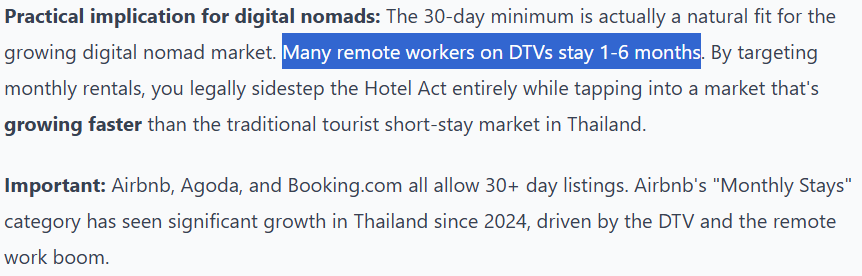

4. Secara logika dan kebanyakan orang pada umumnya hanya menginap 1-7 hari atau bahkan paling lama 30 hari (1 bulan). Menginap selama 500+ hari (>1 tahun) bahkan hingga 1125 hari (nilai max`minimum_nights` pada dataset) dianggap tidak umum. Dari sudut pandang data, nilai 1125 terlihat seperti error. Namun ternyata, jika kita memahami konteks bisnis Airbnb, Menginap >500 hari mungkin saja bisa terjadi. Sehingga outlier tersebut bukanlah error, melainkan bagian dari insight bisnis juga.
5. Setelah dihitung, terdapat 3166 data (~20% keseluruhan data) yang merupakan outlier dari sudut pandang `minimum_nights`. Data tersebut bukan jumlah yang sedikit, sehingga menghilangkan outlier dari dataset bukanlah keputusan yang bijak. Jadi, outlier akan dibiarkan dan menjadi tambahan insight bisnis.

In [34]:
df_clean['stay_category'] = pd.cut(
    df_clean['minimum_nights'],
    bins=[0, 7, 30, 90, 365, df_clean['minimum_nights'].max()],
    labels=['short', 'medium', 'long', 'very_long', 'extreme']
)

df_clean.sort_values(by='minimum_nights', ascending=False)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review,stay_category
61,1041976,Long-stay special rate spacious entire floor Siam,5735895,Pariya,Parthum Wan,13.748140,100.520160,Entire home/apt,2900,1125,295,2021-08-21,2.61,3,0,0,1,extreme
7986,35165443,Wonderful apartment for you holiday in Thai,86991723,Yang,Bang Na,13.672600,100.603520,Entire home/apt,2000,1115,0,NaT,0.00,2,358,0,0,extreme
11524,49032568,Freehold Condo near Bangsue Grand Station,4661237,Chayanid,Bang Sue,13.806970,100.523620,Entire home/apt,554,1095,0,NaT,0.00,1,358,0,0,extreme
10153,41623113,blossom condo舒适双床房摩天轮夜市周边免费泳池健身房@Sathon surasakBTS,162537040,Songnya,Sathon,13.711950,100.520550,Entire home/apt,650,1000,2,2020-03-08,0.06,13,179,0,1,extreme
11243,45051929,Bellevue Boutique Bangkok | Airport Link HUA-MAK,165329146,Sataporn,Suanluang,13.736330,100.638360,Private room,1314,999,0,NaT,0.00,2,181,0,0,extreme
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15843,790458045665867830,Euro LuxuryHotel PratunamMKt TripleBdNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754421,100.538842,Private room,1529,1,0,NaT,0.00,14,363,0,0,short
15841,790451855541607948,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.752631,100.538843,Private room,1214,1,0,NaT,0.00,14,365,0,0,short
15838,790346710454894685,Comfortable Stay in Pratunam,424281953,Saruta,Ratchathewi,13.755000,100.538530,Private room,640,1,0,NaT,0.00,4,365,0,0,short
15837,790344175778149301,Spacious Stay at Pratunam,424281953,Saruta,Ratchathewi,13.754210,100.540580,Private room,640,1,0,NaT,0.00,4,365,0,0,short


*Segmentasi kolom `minimum_nights` berdasarkan lamanya menginap*
| Kategori       | Range         | Makna Bisnis                    |
| -------------- | ------------- | ------------------------------- |
| Short Stay     | 1 – 7 hari    | Wisatawan                       |
| Medium Stay    | 8 – 30 hari   | Liburan panjang / business trip |
| Long Stay      | 31 – 90 hari  | Digital nomad                   |
| Very Long Stay | 91 – 365 hari | Expat / long-term rental        |
| Extreme        | > 365 hari    | Tidak typical Airbnb            |


In [35]:
display(df_clean.describe(include='number'))
display(df_clean.describe(include='object'))

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review
count,1.581100e+04,1.581100e+04,15811.000000,15811.000000,1.581100e+04,15811.000000,15811.000000,15811.000000,15811.000000,15811.000000,15811.000000,15811.000000
mean,1.573259e+17,1.540731e+08,13.745152,100.559905,3.221287e+03,15.326039,16.691291,0.516594,13.757890,244.133768,3.489216,0.635317
std,2.941162e+17,1.318955e+08,0.043045,0.050952,2.500590e+04,50.879038,40.659044,0.953350,29.858582,125.881022,8.927521,0.481356
min,2.793400e+04,5.892000e+04,13.527300,100.329550,2.780000e+02,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.104510e+07,3.974431e+07,13.720120,100.529690,9.000000e+02,1.000000,0.000000,0.000000,1.000000,137.000000,0.000000,0.000000
50%,3.501730e+07,1.223632e+08,13.738500,100.561400,1.428000e+03,1.000000,2.000000,0.090000,4.000000,308.000000,0.000000,1.000000
75%,5.251112e+07,2.389859e+08,13.759510,100.585170,2.443000e+03,7.000000,13.000000,0.670000,13.000000,360.000000,3.000000,1.000000
max,7.908162e+17,4.926659e+08,13.953540,100.923440,1.100000e+06,1125.000000,1224.000000,19.130000,228.000000,365.000000,325.000000,1.000000


,name,host_name,neighbourhood,room_type
count,15811,15811,15811,15811
unique,14792,5305,50,4
top,New! La Chada Night Market studio 2PPL near MRT,Curry,Vadhana,Entire home/apt
freq,45,219,2148,8891


In [36]:
summary = pd.DataFrame({
    'Dataset': ['df (raw)', 'df_clean'],
    'Jumlah Baris': [len(df), len(df_clean)],
    'Jumlah Kolom': [df.shape[1], df_clean.shape[1]]
})

deleted_rows = len(df) - len(df_clean)

print(f"Jumlah baris yang terhapus: {deleted_rows}")
print(f"Persentase data terhapus: {deleted_rows / len(df) * 100:.2f}%")

summary

Jumlah baris yang terhapus: 43
Persentase data terhapus: 0.27%


,Dataset,Jumlah Baris,Jumlah Kolom
0,df (raw),15854,17
1,df_clean,15811,18


*Save dataset ke csv.*

In [37]:
# df_clean.to_csv('Airbnb-listing-bangkok_clean.csv')

*Save dataset ke xlsx.*

In [38]:
# df_clean.to_excel('Airbnb-listing-bangkok_clean.xlsx')

In [39]:
airbnb_eda = df_clean.copy()

In [40]:
print(f'Shape  : {airbnb_eda.shape}')
print(f'Kolom  : {list(airbnb_eda.columns)}')
print()
airbnb_eda.head()

Shape  : (15811, 18)
Kolom  : ['id', 'name', 'host_id', 'host_name', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'has_review', 'stay_category']



,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review,stay_category
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.50,2,353,0,1,short
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaT,0.00,2,358,0,0,short
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,60,0,NaT,0.00,1,365,0,0,long
3,35780,Spacious one bedroom at The Kris Condo Bldg. 3,153730,Sirilak,Din Daeng,13.78823,100.57256,Private room,1286,7,2,2022-04-01,0.03,1,323,1,1,short
4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.76872,100.63338,Private room,1905,1,0,NaT,0.00,3,365,0,0,short


In [41]:
print('=== Data Types & Missing Values ===')
info = pd.DataFrame({
    'dtype': airbnb_eda.dtypes,
    'null_count': airbnb_eda.isnull().sum(),
    'null_pct': (airbnb_eda.isnull().mean() * 100).round(1)
})
print(info.to_string())

=== Data Types & Missing Values ===
                                         dtype  null_count  null_pct
id                                       int64           0       0.0
name                                    object           0       0.0
host_id                                  int64           0       0.0
host_name                               object           0       0.0
neighbourhood                           object           0       0.0
latitude                               float64           0       0.0
longitude                              float64           0       0.0
room_type                               object           0       0.0
price                                    int64           0       0.0
minimum_nights                           int64           0       0.0
number_of_reviews                        int64           0       0.0
last_review                     datetime64[ns]        5766      36.5
reviews_per_month                      float64           0       0.

In [42]:
print('room_type value counts:')
print(airbnb_eda['room_type'].value_counts())
print()
print('stay_category value counts:')
print(airbnb_eda['stay_category'].value_counts())

room_type value counts:
room_type
Entire home/apt    8891
Private room       5753
Hotel room         646 
Shared room        521 
Name: count, dtype: int64

stay_category value counts:
stay_category
short        12072
medium       2871 
very_long    436  
long         417  
extreme      15   
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

In [43]:
# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

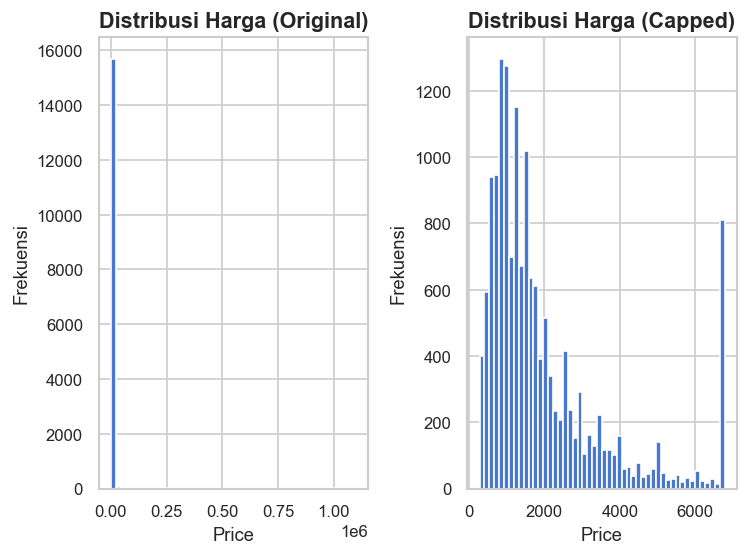

In [44]:
# Sebelum capping
plt.subplot(1,2,1)
plt.hist(airbnb_eda['price'], bins=50)
plt.title('Distribusi Harga (Original)')
plt.xlabel('Price')
plt.ylabel('Frekuensi')

# Cap harga di persentil ke-95 untuk analisis (hapus outlier ekstrem)
price_cap = airbnb_eda['price'].quantile(0.95)
airbnb_eda['price_capped'] = airbnb_eda['price'].clip(upper=price_cap)

# Sesudah capping
plt.subplot(1,2,2)
plt.hist(airbnb_eda['price_capped'], bins=50)
plt.title('Distribusi Harga (Capped)')
plt.xlabel('Price')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

In [45]:
airbnb_eda.sort_values(by='price',ascending=False)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review,stay_category,price_capped
12868,635676064543597376,New 1 bedroom apartment BTS MRT Asoke,12464705,Lucio,Vadhana,13.742186,100.560394,Entire home/apt,1100000,14,0,NaT,0.00,1,365,0,0,medium,6777
12300,562972065309061724,3B中文No Guest Service Fee@Nana Asok/Soi11 Nightlife,131427125,Jj,Vadhana,13.746660,100.559100,Entire home/apt,1014758,30,2,2022-09-17,0.32,10,75,2,1,medium,6777
6289,29909847,BTS轻轨线on nut站，全新一房一厅，临Tesco商场市集!New cozy 1BR,210559448,Cora,Khlong Toei,13.703330,100.592470,Entire home/apt,1000000,2,69,2020-03-12,1.39,6,90,0,1,short,6777
9345,39858231,1BR cozy condo close to ONNUT BTS.,210559448,Cora,Khlong Toei,13.704960,100.591510,Entire home/apt,1000000,25,2,2020-02-23,0.05,6,88,0,1,medium,6777
4620,23740993,"Modern&Luxury apartment,5min to MRT,freeWifi",30803267,Yasmine,Huai Khwang,13.760650,100.568980,Entire home/apt,1000000,1,12,2020-03-24,0.22,4,336,0,1,short,6777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15473,780103082979427963,Flourish Capsule Hostel,491129139,Chirapat,Bang Rak,13.732114,100.526675,Shared room,295,1,1,2022-12-19,1.00,1,176,1,1,short,295
15455,776042168224443103,1 Upper-Bunk Bed /w Shared Bath,219048748,Kay,Suanluang,13.712770,100.606230,Shared room,280,1,0,NaT,0.00,7,365,0,0,short,280
15401,772815799000677300,Mixed Dorm 10 Bunkbed at Amazing khaosan Hostel 2,488818866,Thanet,Phra Nakhon,13.762439,100.503922,Shared room,280,1,0,NaT,0.00,12,356,0,0,short,280
15456,776071884102373052,1 Lower-Bunk Bed /w Shared Bath,219048748,Kay,Suanluang,13.711320,100.605730,Shared room,280,1,0,NaT,0.00,7,365,0,0,short,280


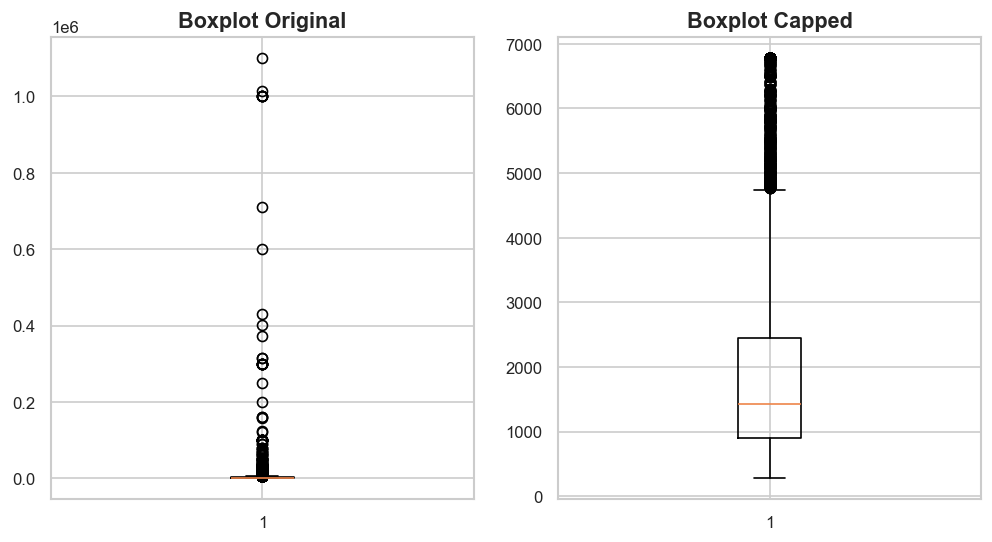

In [46]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(airbnb_eda['price'])
plt.title('Boxplot Original')

plt.subplot(1,2,2)
plt.boxplot(airbnb_eda['price_capped'])
plt.title('Boxplot Capped')

plt.show()

In [47]:
comparison = pd.DataFrame({
    'Original': airbnb_eda['price'].describe(),
    'Capped': airbnb_eda['price_capped'].describe()
})

comparison

,Original,Capped
count,1.581100e+04,15811.000000
mean,3.221287e+03,1975.480741
std,2.500590e+04,1614.935160
min,2.780000e+02,278.000000
25%,9.000000e+02,900.000000
50%,1.428000e+03,1428.000000
75%,2.443000e+03,2443.000000
max,1.100000e+06,6777.000000


*Distribusi harga awal menunjukkan adanya right-skewness akibat outlier ekstrem. Setelah dilakukan capping pada persentil ke-95, distribusi menjadi lebih stabil tanpa menghilangkan data, sehingga lebih representatif untuk analisis lebih lanjut.*

### 3.1 Feature Engineering — Spatial Features

Kita hitung jarak dari setiap listing ke:
- **Pusat kota Bangkok** (Siam / CentralWorld: 13.7462°N, 100.5347°E)
- **Stasiun BTS** utama (Asok, Silom)
- **Destinasi wisata** (Wat Pho, Khao San Road, Chatucak Market)
- **Bandara** (Suvarnabhumi, Don Mueang)

Menggunakan formula **Haversine** untuk jarak geodesik.

In [48]:
def haversine(lat1, lon1, lat2, lon2):
    """Hitung jarak geodesik (km) antara dua titik koordinat."""
    R = 6371  # radius bumi (km)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi   = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


# --- Pusat kota (Siam / CentralWorld) ---
CENTER_LAT, CENTER_LON = 13.7462, 100.5347
airbnb_eda['dist_center_km'] = haversine(airbnb_eda['latitude'], airbnb_eda['longitude'], CENTER_LAT, CENTER_LON)

# --- Transportasi & destinasi wisata ---
landmarks = {
    'asok_bts'          : (13.7369, 100.5608),
    'silom_bts'         : (13.7284, 100.5344),
    'chatuchak_market'  : (13.7999, 100.5500),
    'khao_san_road'     : (13.7582, 100.4972),
    'wat_pho'           : (13.7465, 100.4934),
    'suvarnabhumi_apt'  : (13.6900, 100.7501),
    'don_mueang_apt'    : (13.9126, 100.6070),
}

for name, (lat, lon) in landmarks.items():
    airbnb_eda[f'dist_{name}_km'] = haversine(airbnb_eda['latitude'], airbnb_eda['longitude'], lat, lon)

# Jarak ke BTS terdekat (min antara Asok & Silom)
airbnb_eda['dist_nearest_bts_km'] = airbnb_eda[['dist_asok_bts_km', 'dist_silom_bts_km']].min(axis=1)

# --- Binning zona jarak ---
airbnb_eda['dist_zone'] = pd.cut(
    airbnb_eda['dist_center_km'],
    bins=[0, 3, 6, 10, 20, 100],
    labels=['0-3 km', '3-6 km', '6-10 km', '10-20 km', '20km+']
)

airbnb_eda['bts_zone'] = pd.cut(
    airbnb_eda['dist_nearest_bts_km'],
    bins=[0, 1, 2, 4, 8, 50],
    labels=['<1 km', '1-2 km', '2-4 km', '4-8 km', '8km+']
)

print(f'Features spatial berhasil dibuat. price_cap (p95) = {price_cap:,.0f} THB')
airbnb_eda[['dist_center_km', 'dist_nearest_bts_km', 'dist_zone', 'bts_zone']].describe(include='all')

Features spatial berhasil dibuat. price_cap (p95) = 6,777 THB


,dist_center_km,dist_nearest_bts_km,dist_zone,bts_zone
count,15811.000000,15811.000000,15811,15811
unique,NaN,NaN,5,5
top,NaN,NaN,3-6 km,4-8 km
freq,NaN,NaN,6103,4539
mean,6.263736,5.037937,NaN,NaN
std,4.624346,4.570667,NaN,NaN
min,0.047551,0.027027,NaN,NaN
25%,3.170794,1.853028,NaN,NaN
50%,5.035496,3.641326,NaN,NaN
75%,7.950218,6.679394,NaN,NaN


### 3.2 Landmark Mapping

In [ ]:
center_lat = airbnb_eda['latitude'].mean()
center_lon = airbnb_eda['longitude'].mean()

print(center_lat, center_lon)

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12
)

folium.Marker(
    location=[center_lat, center_lon],
    popup='Pusat Airbnb (Centroid)',
    icon=folium.Icon(color='red', icon='info-sign')
).add_to(m)

landmarks = {
    'Asok BTS': (13.7369, 100.5608),
    'Silom BTS': (13.7284, 100.5344),
    'Chatuchak Market': (13.7999, 100.5500),
    'Khao San Road': (13.7582, 100.4972),
    'Wat Pho': (13.7465, 100.4934),
    'Suvarnabhumi Airport': (13.6900, 100.7501),
    'Don Mueang Airport': (13.9126, 100.6070),
}

for name, (lat, lon) in landmarks.items():
    folium.Marker(
        location=[lat, lon],
        popup=name,
        icon=folium.Icon(color='blue', icon='star')
    ).add_to(m)
    
    sample_df = airbnb_eda.sample(1000, random_state=42)

for _, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        fill=True
    ).add_to(m)

CENTER_LAT, CENTER_LON = 13.7462, 100.5347

folium.Marker(
    location=[CENTER_LAT, CENTER_LON],
    popup='Pusat Kota (Siam)',
    icon=folium.Icon(color='green', icon='home')
).add_to(m)

    
m

13.745152343128165 100.5599049153631


### 3.3 Analisis Korelasi - Spatial vs Performa

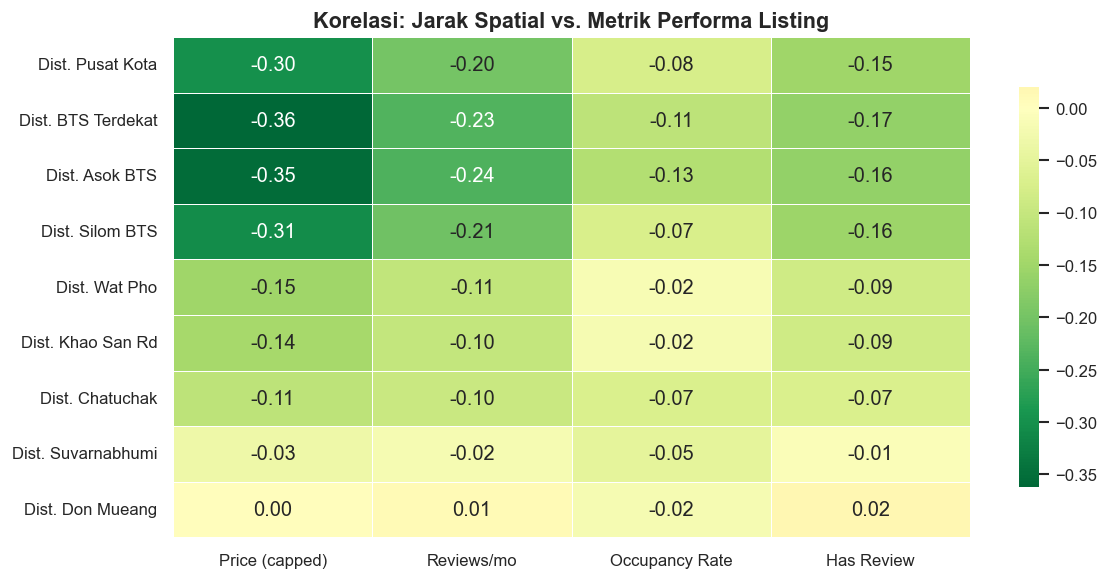


--- Korelasi dengan price_capped (diurutkan) ---
dist_nearest_bts_km        -0.362091
dist_asok_bts_km           -0.353749
dist_silom_bts_km          -0.306252
dist_center_km             -0.301296
dist_wat_pho_km            -0.151735
dist_khao_san_road_km      -0.143998
dist_chatuchak_market_km   -0.111950
dist_suvarnabhumi_apt_km   -0.031061
dist_don_mueang_apt_km      0.002849
Name: price_capped, dtype: float64

--- Korelasi dengan reviews_per_month (diurutkan) ---
dist_asok_bts_km           -0.236814
dist_nearest_bts_km        -0.234405
dist_silom_bts_km          -0.206419
dist_center_km             -0.200890
dist_wat_pho_km            -0.106016
dist_khao_san_road_km      -0.104027
dist_chatuchak_market_km   -0.096196
dist_suvarnabhumi_apt_km   -0.018813
dist_don_mueang_apt_km      0.012153
Name: reviews_per_month, dtype: float64

--- Korelasi dengan occupancy_rate (diurutkan) ---
dist_asok_bts_km           -0.126037
dist_nearest_bts_km        -0.110580
dist_center_km             -

In [50]:
# ======================
# Feature Engineering
# ======================
airbnb_eda['occupancy_rate'] = (365 - airbnb_eda['availability_365']) / 365

# ======================
# Columns
# ======================
spatial_cols = [
    'dist_center_km', 'dist_nearest_bts_km',
    'dist_asok_bts_km', 'dist_silom_bts_km',
    'dist_wat_pho_km', 'dist_khao_san_road_km',
    'dist_chatuchak_market_km',
    'dist_suvarnabhumi_apt_km', 'dist_don_mueang_apt_km',
]

perf_cols = ['price_capped', 'reviews_per_month', 'occupancy_rate', 'has_review']

# ======================
# Correlation
# ======================
corr_matrix = airbnb_eda[spatial_cols + perf_cols].corr(method='spearman')
sub_corr = corr_matrix.loc[spatial_cols, perf_cols]

# ======================
# Plot Heatmap
# ======================
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    sub_corr, annot=True, fmt='.2f', center=0,
    cmap='RdYlGn_r', linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.8}
)

ax.set_title('Korelasi: Jarak Spatial vs. Metrik Performa Listing')

ax.set_xticklabels([
    'Price (capped)', 'Reviews/mo', 'Occupancy Rate', 'Has Review'
], rotation=0)

ax.set_yticklabels([
    'Dist. Pusat Kota', 'Dist. BTS Terdekat',
    'Dist. Asok BTS', 'Dist. Silom BTS',
    'Dist. Wat Pho', 'Dist. Khao San Rd',
    'Dist. Chatuchak', 'Dist. Suvarnabhumi', 'Dist. Don Mueang'
], rotation=0)

plt.tight_layout()
plt.show()

# ======================
# Insight tambahan
# ======================
print('\n--- Korelasi dengan price_capped (diurutkan) ---')
print(sub_corr['price_capped'].sort_values())

print('\n--- Korelasi dengan reviews_per_month (diurutkan) ---')
print(sub_corr['reviews_per_month'].sort_values())

print('\n--- Korelasi dengan occupancy_rate (diurutkan) ---')
print(sub_corr['occupancy_rate'].sort_values())

### 3.4 Analisis Zona Jarak ke Pusat Kota

In [51]:
zone_agg = airbnb_eda.groupby('dist_zone', observed=True).agg(
    jumlah_listing  = ('id', 'count'),
    median_price    = ('price_capped', 'median'),
    mean_rpm        = ('reviews_per_month', 'mean'),
    mean_occupancy  = ('occupancy_rate', 'mean'),
    pct_has_review  = ('has_review', 'mean'),
).round(2)

zone_agg['pct_has_review'] = (zone_agg['pct_has_review'] * 100).round(1)

print(zone_agg.to_string())

           jumlah_listing  median_price  mean_rpm  mean_occupancy  pct_has_review
dist_zone                                                                        
0-3 km               3593        1879.0      0.70            0.34            72.0
3-6 km               6103        1500.0      0.58            0.34            66.0
6-10 km              3588        1100.0      0.42            0.34            60.0
10-20 km             2152         990.0      0.22            0.29            49.0
20km+                 375         990.0      0.37            0.26            49.0


C:\Users\user\AppData\Local\Temp\ipykernel_36424\2398925919.py:64: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\anaconda3\envs\jcdsbsdpm32\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


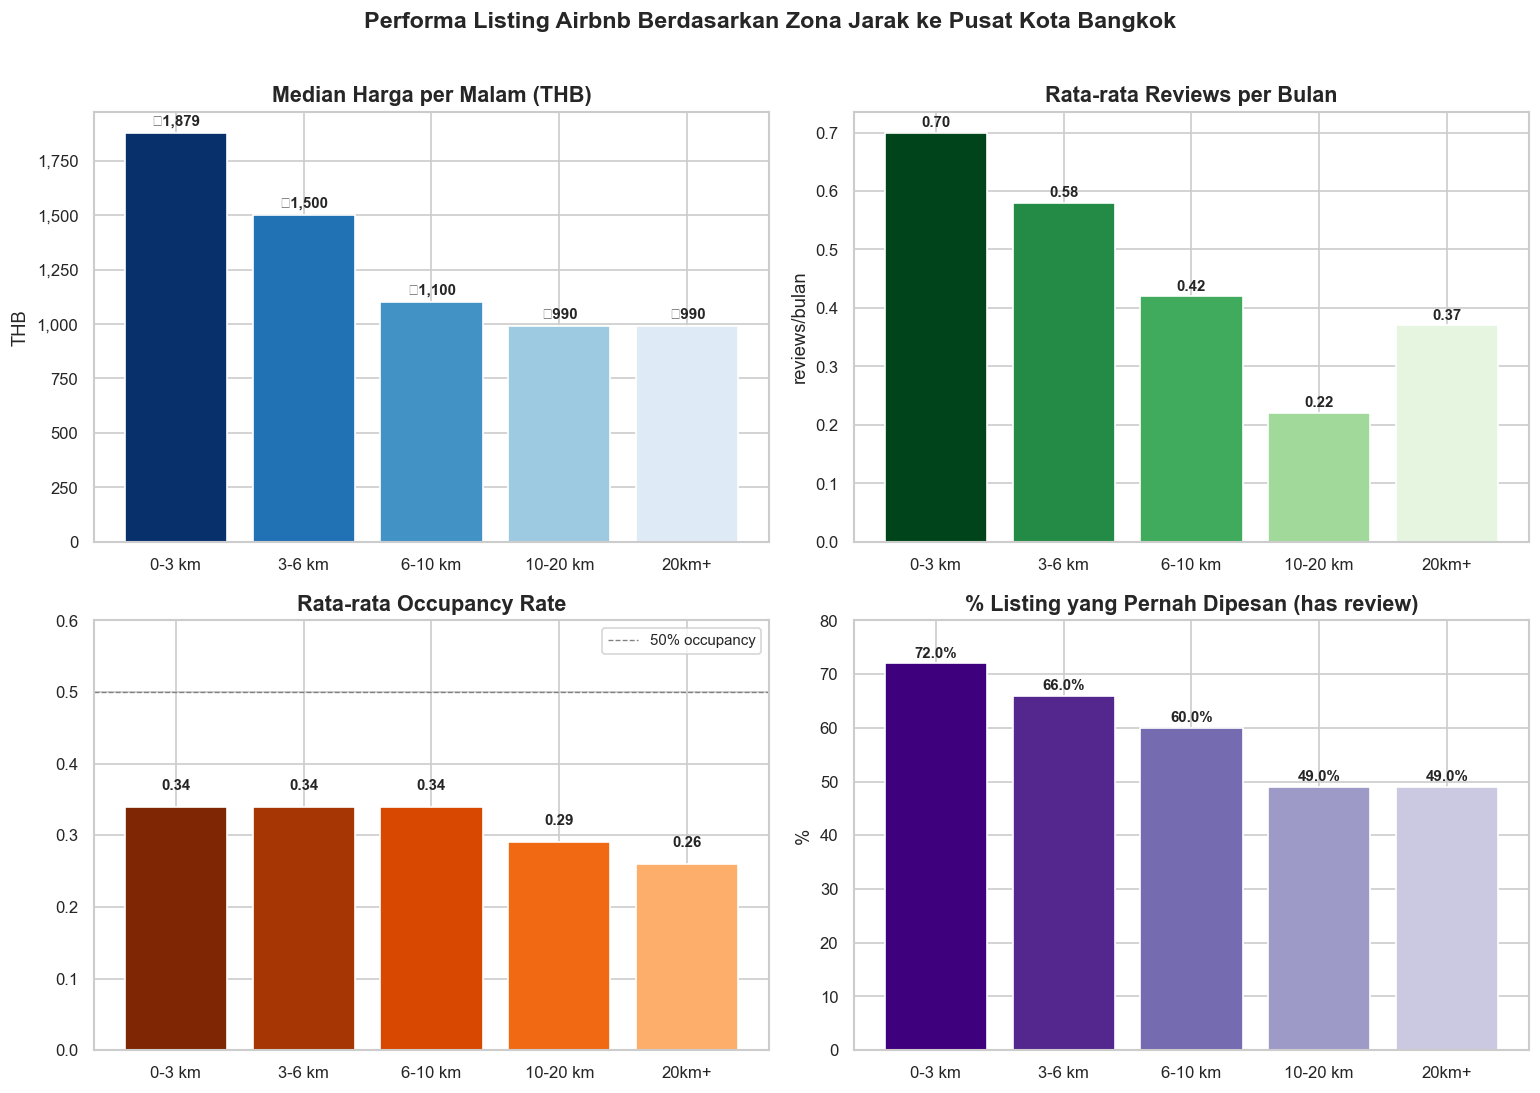

In [ ]:
zones = zone_agg.index.tolist()

colors_blue  = ['#08306b', '#2171b5', '#4292c6', '#9ecae1', '#deebf7']
colors_green = ['#00441b', '#238b45', '#41ab5d', '#a1d99b', '#e5f5e0']
gradient_o = ['#7f2704', '#a63603', '#d94801', '#f16913', '#fdae6b']
gradient_p = ['#3f007d', '#54278f', '#756bb1', '#9e9ac8', '#cbc9e2']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Performa Listing Airbnb Berdasarkan Zona Jarak ke Pusat Kota Bangkok', fontsize=14, fontweight='bold', y=1.01)

# 1. Median Price
ax = axes[0, 0]
bars = ax.bar(zones, zone_agg['median_price'], color=colors_blue)
ax.set_title('Median Harga per Malam (THB)')
ax.set_ylabel('THB')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val in zip(bars, zone_agg['median_price']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'฿{int(val):,}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# 2. Reviews per month
ax = axes[0, 1]
bars = ax.bar(zones, zone_agg['mean_rpm'], color=colors_green)
ax.set_title('Rata-rata Reviews per Bulan')
ax.set_ylabel('reviews/bulan')

for bar, val in zip(bars, zone_agg['mean_rpm']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# 3. Occupancy Rate
ax = axes[1, 0]
bars = ax.bar(zones, zone_agg['mean_occupancy'], color=gradient_o)

ax.set_title('Rata-rata Occupancy Rate')

# Skala tetap 0–0.6
ax.set_ylim(0, 0.6)

# Garis 50% occupancy (0.5 dalam desimal)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% occupancy')
ax.legend(fontsize=9)

# Label di atas bar → persen
for bar, val in zip(bars, zone_agg['mean_occupancy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# 4. % Has review
ax = axes[1, 1]
bars = ax.bar(zones, zone_agg['pct_has_review'], color=gradient_p)
ax.set_title('% Listing yang Pernah Dipesan (has review)')
ax.set_ylabel('%')
ax.set_ylim(0, 80)
for bar, val in zip(bars, zone_agg['pct_has_review']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.5 Analisis Akses BTS (Bangkok Mass Transit System/Pusat Sistem Transit di Bangkok) Skytrain

          jumlah_listing  mean_price  median_price  mean_rpm  occupancy_rate  pct_has_review
bts_zone                                                                                    
<1 km               1728    2846.947        2271.0     0.902           0.367            73.6
1-2 km              2457    2323.343        1744.0     0.662           0.345            73.3
2-4 km              4035    2124.793        1507.0     0.546           0.332            64.8
4-8 km              4539    1643.525        1139.0     0.432           0.334            62.0
8km+                3052    1498.312         993.0     0.268           0.294            50.6


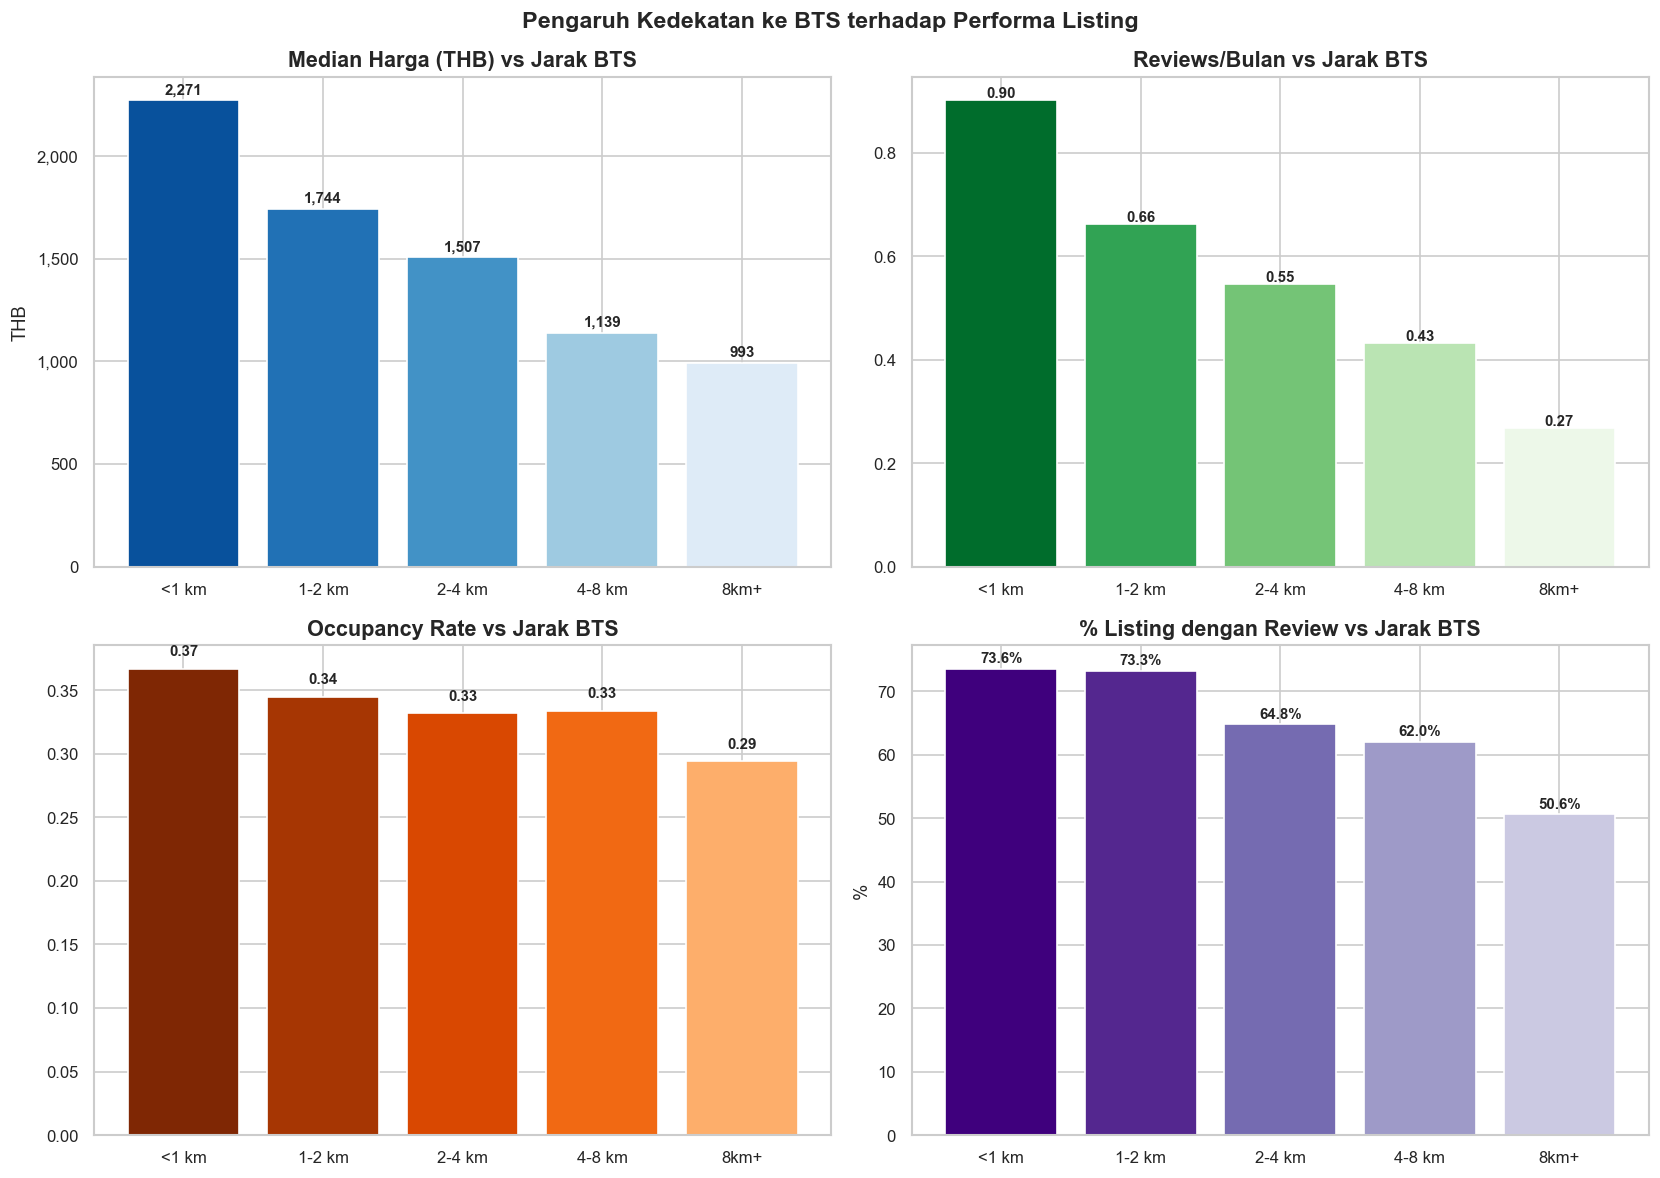


BTS premium (<1km vs terjauh): 2.3x harga lebih tinggi
Demand multiplier: 3.4x lebih banyak reviews/bulan
Occupancy multiplier: 1.2x lebih tinggi
Conversion gap: 23.0% lebih banyak listing punya review


In [53]:
# ======================
# Aggregation (update)
# ======================
bts_agg = airbnb_eda.groupby('bts_zone', observed=True).agg(
    jumlah_listing = ('id', 'count'),
    mean_price     = ('price_capped', 'mean'),
    median_price   = ('price_capped', 'median'),
    mean_rpm       = ('reviews_per_month', 'mean'),
    occupancy_rate = ('occupancy_rate', 'mean'),
    pct_has_review = ('has_review', 'mean'),
).round(3)

bts_agg['pct_has_review'] = (bts_agg['pct_has_review'] * 100).round(1)

print(bts_agg.to_string())

# ======================
# Color Gradients
# ======================
bts_zones = bts_agg.index.tolist()

gradient_b = ['#08519c', '#2171b5', '#4292c6', '#9ecae1', '#deebf7']
gradient_g = ['#006d2c', '#31a354', '#74c476', '#bae4b3', '#edf8e9']
gradient_o = ['#7f2704', '#a63603', '#d94801', '#f16913', '#fdae6b']
gradient_p = ['#3f007d', '#54278f', '#756bb1', '#9e9ac8', '#cbc9e2']

# ======================
# Visualization
# ======================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pengaruh Kedekatan ke BTS terhadap Performa Listing', fontsize=14, fontweight='bold')

# ======================
# 1. MEDIAN PRICE
# ======================
ax = axes[0, 0]
bars = ax.bar(bts_zones, bts_agg['median_price'], color=gradient_b)
ax.set_title('Median Harga (THB) vs Jarak BTS')
ax.set_ylabel('THB')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val in zip(bars, bts_agg['median_price']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(val):,}', ha='center', fontsize=9, fontweight='bold')

# ======================
# 2. REVIEWS PER MONTH
# ======================
ax = axes[0, 1]
bars = ax.bar(bts_zones, bts_agg['mean_rpm'], color=gradient_g)
ax.set_title('Reviews/Bulan vs Jarak BTS')

for bar, val in zip(bars, bts_agg['mean_rpm']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# ======================
# 3. OCCUPANCY RATE
# ======================
ax = axes[1, 0]
bars = ax.bar(bts_zones, bts_agg['occupancy_rate'], color=gradient_o)
ax.set_title('Occupancy Rate vs Jarak BTS')

for bar, val in zip(bars, bts_agg['occupancy_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# ======================
# 4. % HAS REVIEW
# ======================
ax = axes[1, 1]
bars = ax.bar(bts_zones, bts_agg['pct_has_review'], color=gradient_p)
ax.set_title('% Listing dengan Review vs Jarak BTS')
ax.set_ylabel('%')

for bar, val in zip(bars, bts_agg['pct_has_review']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ======================
# Insight Metrics
# ======================
price_mult = bts_agg['median_price'].iloc[0] / bts_agg['median_price'].iloc[-1]
rpm_mult   = bts_agg['mean_rpm'].iloc[0] / bts_agg['mean_rpm'].iloc[-1]
occ_mult   = bts_agg['occupancy_rate'].iloc[0] / bts_agg['occupancy_rate'].iloc[-1]
rev_pct    = bts_agg['pct_has_review'].iloc[0] - bts_agg['pct_has_review'].iloc[-1]

print(f'\nBTS premium (<1km vs terjauh): {price_mult:.1f}x harga lebih tinggi')
print(f'Demand multiplier: {rpm_mult:.1f}x lebih banyak reviews/bulan')
print(f'Occupancy multiplier: {occ_mult:.1f}x lebih tinggi')
print(f'Conversion gap: {rev_pct:.1f}% lebih banyak listing punya review')

### 3.6 Analisis Neighbourhood

Top 10 Neighbourhood:
               jumlah_listing  median_price  mean_rpm  mean_occupancy  pct_has_review  mean_dist_center  mean_dist_bts
neighbourhood                                                                                                         
Vadhana                  2148        2000.0      0.65            0.38            65.0              4.55           2.03
Khlong Toei              2087        1700.0      0.86            0.37            77.0              4.89           2.26
Huai Khwang              1123        1351.0      0.48            0.45            66.0              5.22           3.78
Ratchathewi              1110        1539.5      0.55            0.29            69.0              1.58           2.42
Bang Rak                  826        1850.0      0.56            0.32            71.0              2.53           1.13
Sathon                    802        1295.0      0.67            0.28            71.0              3.64           1.92
Phra Nakhon               

C:\Users\user\AppData\Local\Temp\ipykernel_36424\1440803681.py:106: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\anaconda3\envs\jcdsbsdpm32\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


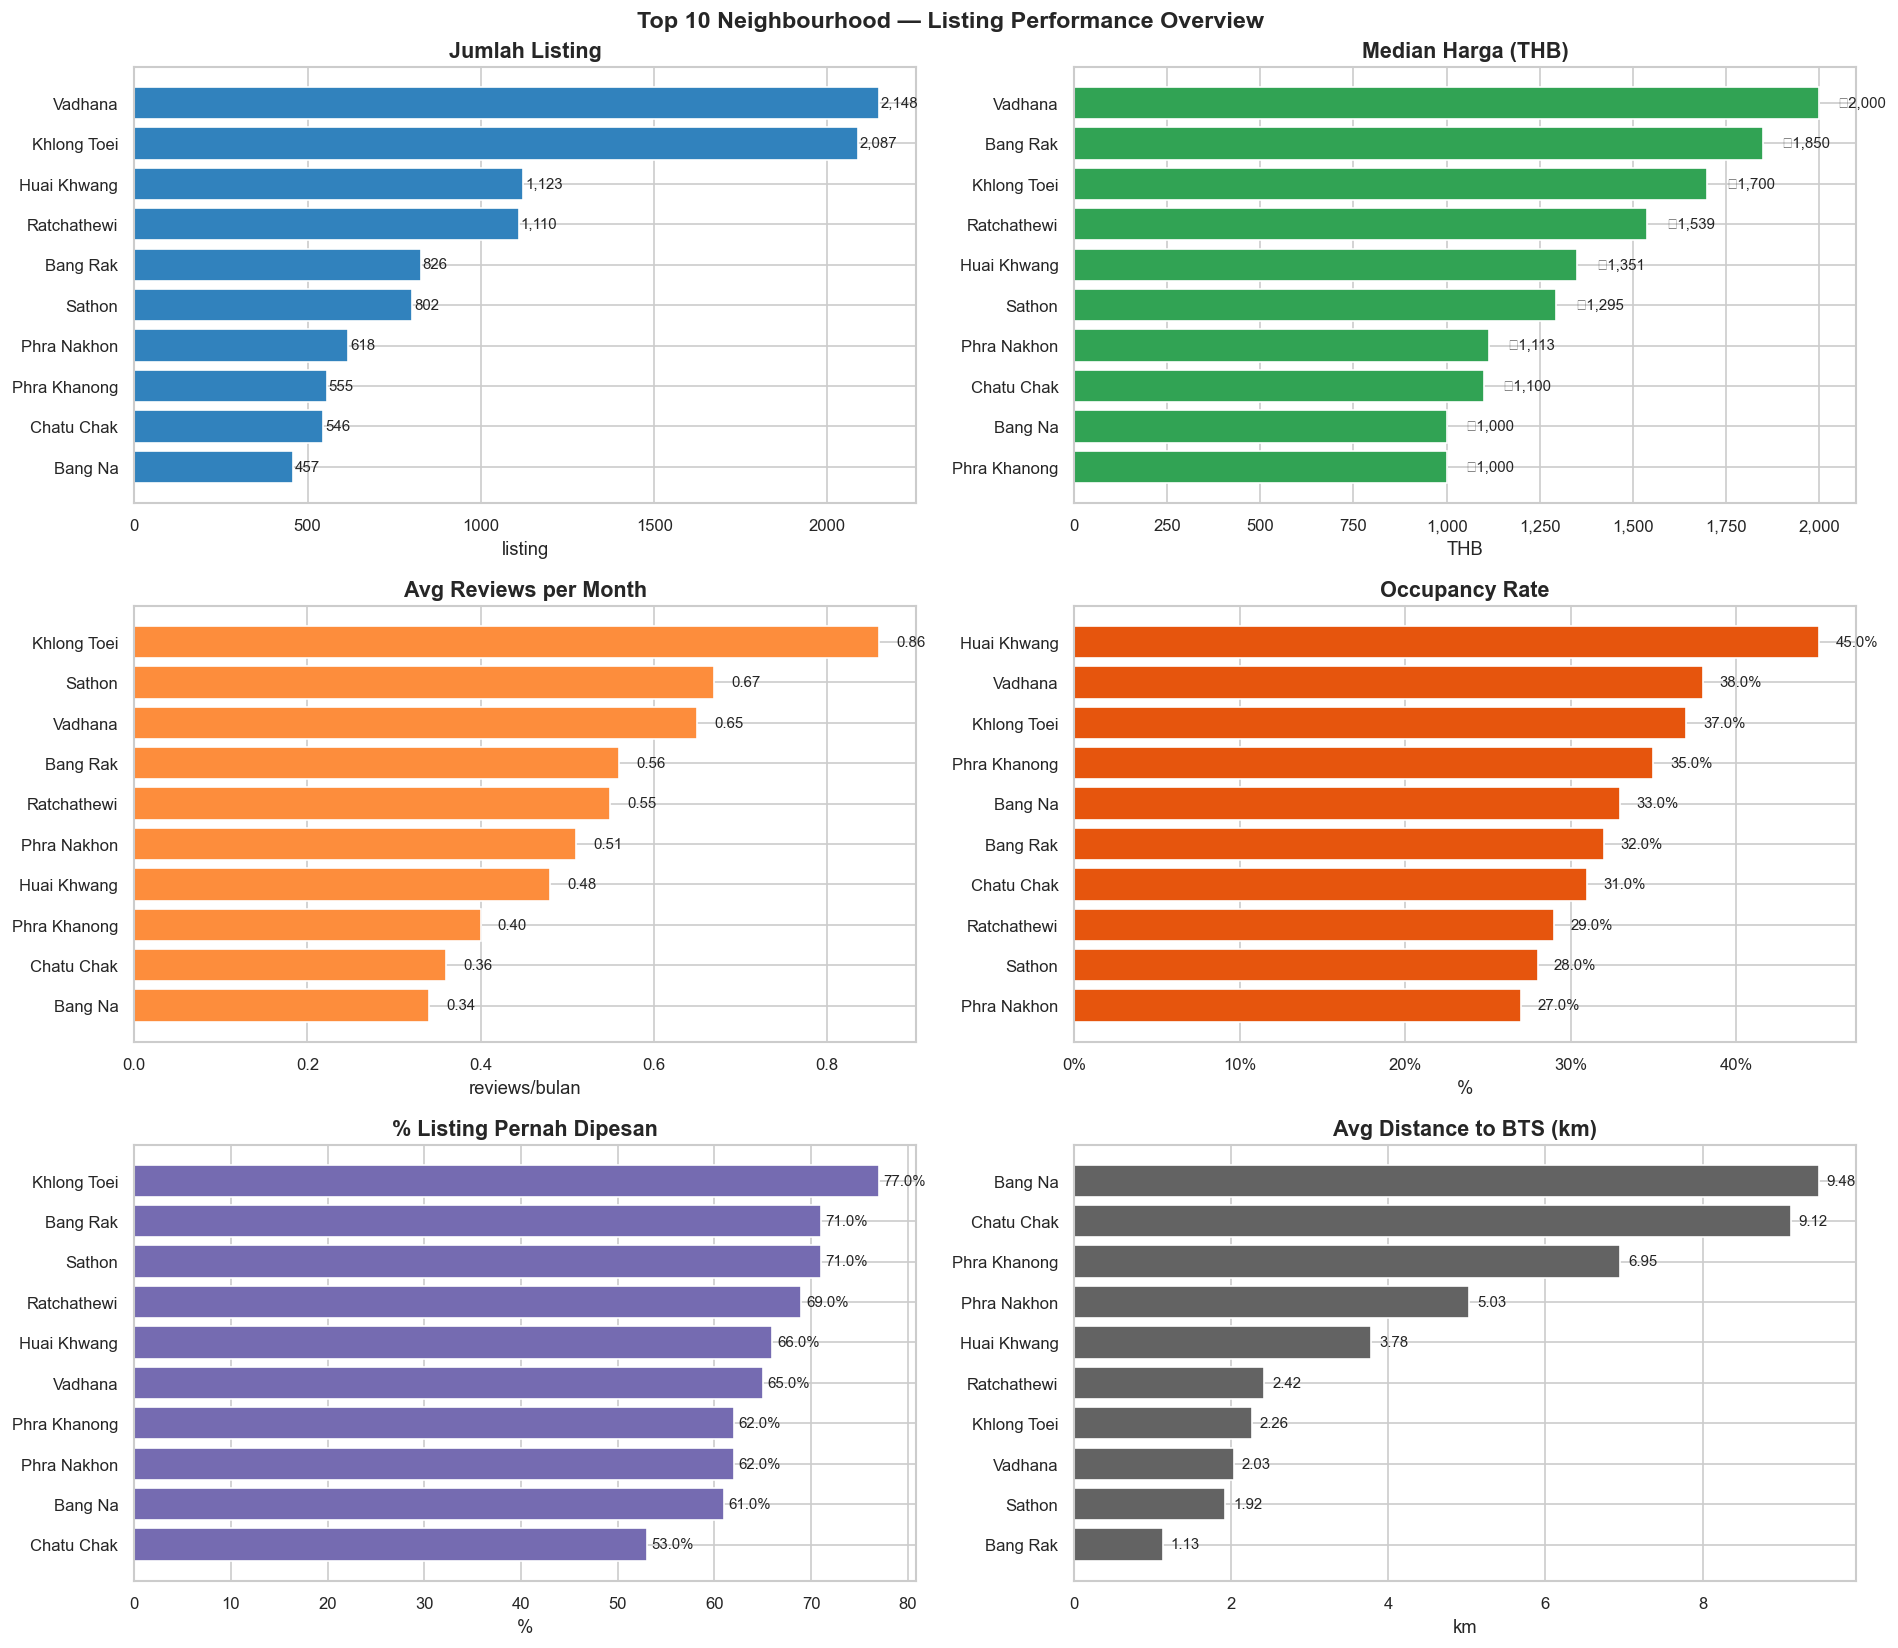

In [61]:
# ======================
# Aggregation
# ======================
nbh_agg = airbnb_eda.groupby('neighbourhood').agg(
    jumlah_listing   = ('id', 'count'),
    median_price     = ('price_capped', 'median'),
    mean_rpm         = ('reviews_per_month', 'mean'),
    mean_occupancy   = ('occupancy_rate', 'mean'),
    pct_has_review   = ('has_review', 'mean'),
    mean_dist_center = ('dist_center_km', 'mean'),
    mean_dist_bts    = ('dist_nearest_bts_km', 'mean'),
).round(2)

# Convert %
nbh_agg['pct_has_review'] = (nbh_agg['pct_has_review'] * 100).round(1)

# ======================
# Top 10
# ======================
nbh_top10 = nbh_agg.nlargest(10, 'jumlah_listing')

print('Top 10 Neighbourhood:')
print(nbh_top10.to_string())

# ======================
# VISUALISASI (ALL METRICS)
# ======================
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Top 10 Neighbourhood — Listing Performance Overview', fontsize=14, fontweight='bold')

# 1. Listing Count
ax = axes[0, 0]
data = nbh_top10.sort_values('jumlah_listing')
ax.barh(data.index, data['jumlah_listing'], color='#3182bd')
ax.set_title('Jumlah Listing')
ax.set_xlabel('listing')
for bar, val in zip(ax.patches, data['jumlah_listing']):
    ax.text(bar.get_width() + 5,
            bar.get_y() + bar.get_height()/2,
            f'{int(val):,}',
            va='center', fontsize=9)

# 2. Median Price
ax = axes[0, 1]
data = nbh_top10.sort_values('median_price')
ax.barh(data.index, data['median_price'], color='#31a354')
ax.set_title('Median Harga (THB)')
ax.set_xlabel('THB')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(ax.patches, data['median_price']):
    ax.text(bar.get_width() + 50,
            bar.get_y() + bar.get_height()/2,
            f'฿{int(val):,}',
            va='center', fontsize=9)

# 3. Reviews per Month
ax = axes[1, 0]
data = nbh_top10.sort_values('mean_rpm')
ax.barh(data.index, data['mean_rpm'], color='#fd8d3c')
ax.set_title('Avg Reviews per Month')
ax.set_xlabel('reviews/bulan')
for bar, val in zip(ax.patches, data['mean_rpm']):
    ax.text(bar.get_width() + 0.02,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}',
            va='center', fontsize=9)

# 4. Occupancy Rate
ax = axes[1, 1]
data = nbh_top10.sort_values('mean_occupancy')
bars = ax.barh(data.index, data['mean_occupancy'], color='#e6550d')
ax.set_title('Occupancy Rate')
ax.set_xlabel('%')

# Format persen
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

# Label
for bar, val in zip(bars, data['mean_occupancy']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=9)

# 5. % Has Review
ax = axes[2, 0]
data = nbh_top10.sort_values('pct_has_review')
bars = ax.barh(data.index, data['pct_has_review'], color='#756bb1')
ax.set_title('% Listing Pernah Dipesan')
ax.set_xlabel('%')

for bar, val in zip(bars, data['pct_has_review']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

# 6. Distance to BTS
ax = axes[2, 1]
data = nbh_top10.sort_values('mean_dist_bts')
ax.barh(data.index, data['mean_dist_bts'], color='#636363')
ax.set_title('Avg Distance to BTS (km)')
ax.set_xlabel('km')
for bar, val in zip(ax.patches, data['mean_dist_bts']):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

Top 10 Neighbourhood:
               jumlah_listing  median_price  mean_rpm  mean_occupancy  pct_has_review  mean_dist_center  mean_dist_bts
neighbourhood                                                                                                         
Vadhana                  2148        2000.0      0.65            0.38            65.0              4.55           2.03
Khlong Toei              2087        1700.0      0.86            0.37            77.0              4.89           2.26
Huai Khwang              1123        1351.0      0.48            0.45            66.0              5.22           3.78
Ratchathewi              1110        1539.5      0.55            0.29            69.0              1.58           2.42
Bang Rak                  826        1850.0      0.56            0.32            71.0              2.53           1.13
Sathon                    802        1295.0      0.67            0.28            71.0              3.64           1.92
Phra Nakhon               

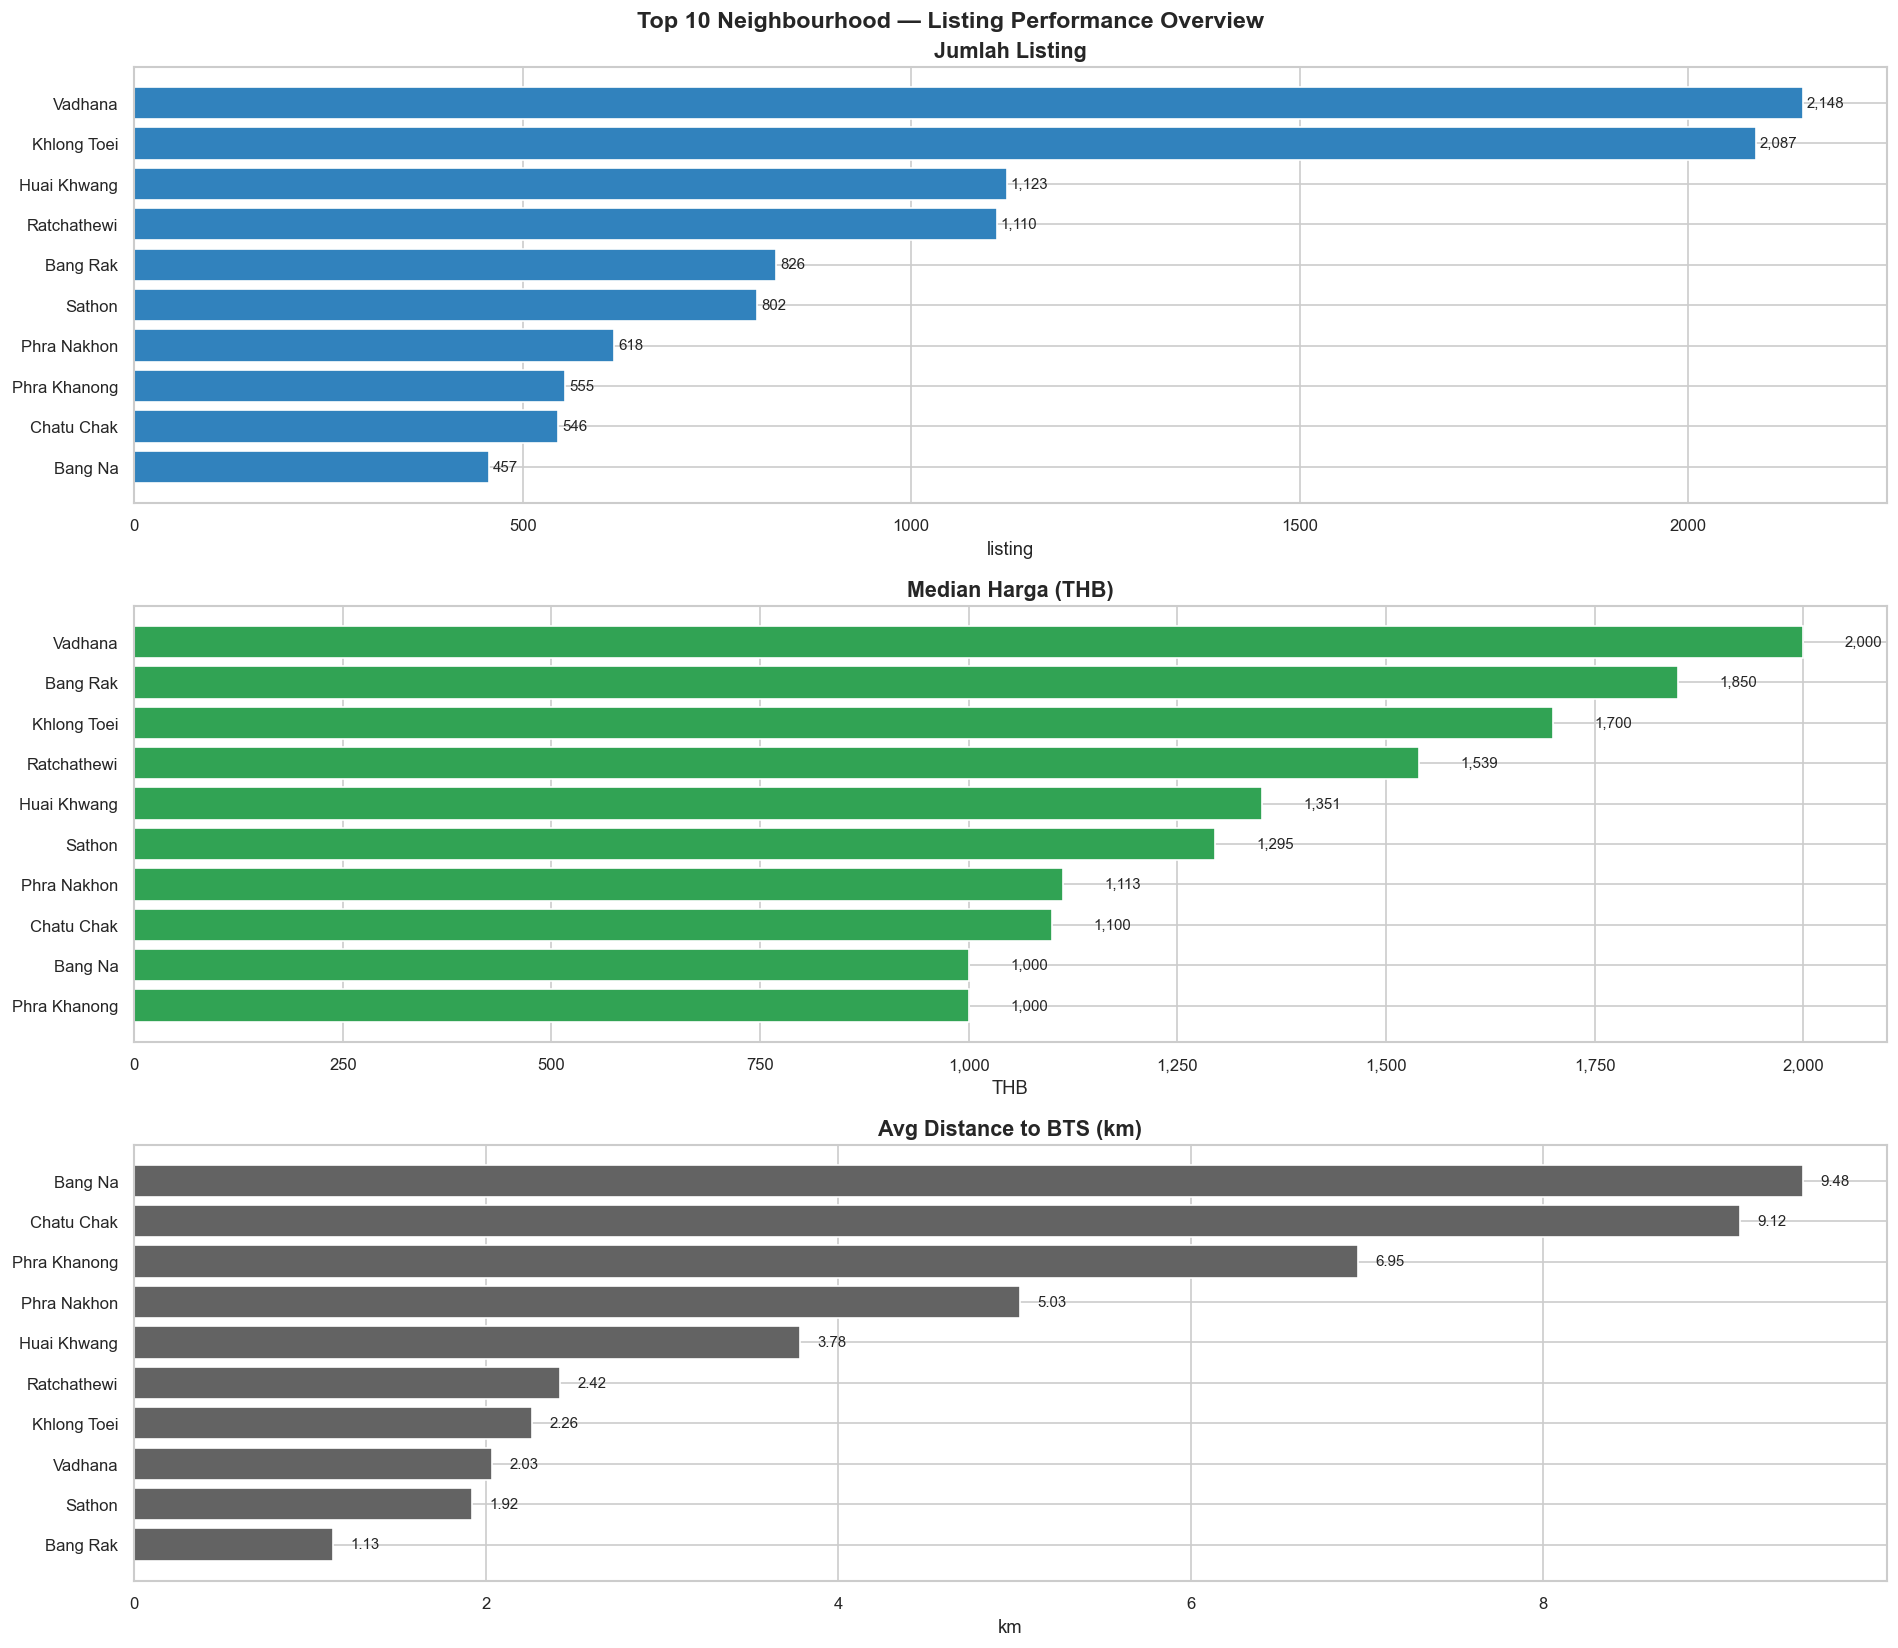

In [ ]:
# ======================
# Top 10
# ======================
nbh_top10 = nbh_agg.nlargest(10, 'jumlah_listing')

print('Top 10 Neighbourhood:')
print(nbh_top10.to_string())

# ======================
# VISUALISASI (ALL METRICS)
# ======================
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('Top 10 Neighbourhood — Listing Performance Overview', fontsize=14, fontweight='bold')

# 1. Listing Count
ax = axes[0]
data = nbh_top10.sort_values('jumlah_listing')
ax.barh(data.index, data['jumlah_listing'], color='#3182bd')
ax.set_title('Jumlah Listing')
ax.set_xlabel('listing')
for bar, val in zip(ax.patches, data['jumlah_listing']):
    ax.text(bar.get_width() + 5,
            bar.get_y() + bar.get_height()/2,
            f'{int(val):,}',
            va='center', fontsize=9)
    
# 2. Median Price
ax = axes[1]
data = nbh_top10.sort_values('median_price')
ax.barh(data.index, data['median_price'], color='#31a354')
ax.set_title('Median Harga (THB)')
ax.set_xlabel('THB')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(ax.patches, data['median_price']):
    ax.text(bar.get_width() + 50,
            bar.get_y() + bar.get_height()/2,
            f'{int(val):,}',
            va='center', fontsize=9)
    
# 3. Distance to BTS
ax = axes[2]
data = nbh_top10.sort_values('mean_dist_bts')
ax.barh(data.index, data['mean_dist_bts'], color='#636363')
ax.set_title('Avg Distance to BTS (km)')
ax.set_xlabel('km')
for bar, val in zip(ax.patches, data['mean_dist_bts']):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [84]:
# ======================
# Booking Rate Category
# ======================
def categorize_booking(rpm):
    if rpm > 0.7:
        return 'Tinggi'
    elif rpm >= 0.3:
        return 'Sedang'
    else:
        return 'Rendah'

nbh_top10['booking_rate'] = nbh_top10['mean_rpm'].apply(categorize_booking)

# ======================
# Final Table
# ======================
final_table = nbh_top10[[
    'jumlah_listing',
    'median_price',
    'mean_rpm',
    'booking_rate',
    'mean_dist_bts'
]].sort_values('jumlah_listing', ascending=False)

# Rename biar clean
final_table.columns = [
    'Jumlah Listing',
    'Median Harga (THB)',
    'Reviews per Month',
    'Booking Rate',
    'Jarak ke BTS (km)'
]

print(final_table.to_string())

               Jumlah Listing  Median Harga (THB)  Reviews per Month Booking Rate  Jarak ke BTS (km)
neighbourhood                                                                                       
Vadhana                  2148              2000.0               0.65       Sedang               2.03
Khlong Toei              2087              1700.0               0.86       Tinggi               2.26
Huai Khwang              1123              1351.0               0.48       Sedang               3.78
Ratchathewi              1110              1539.5               0.55       Sedang               2.42
Bang Rak                  826              1850.0               0.56       Sedang               1.13
Sathon                    802              1295.0               0.67       Sedang               1.92
Phra Nakhon               618              1113.0               0.51       Sedang               5.03
Phra Khanong              555              1000.0               0.40       Sedang          

### 3.7 Komposisi Room Type per Zona Jarak ke Pusat Kota dan BTS

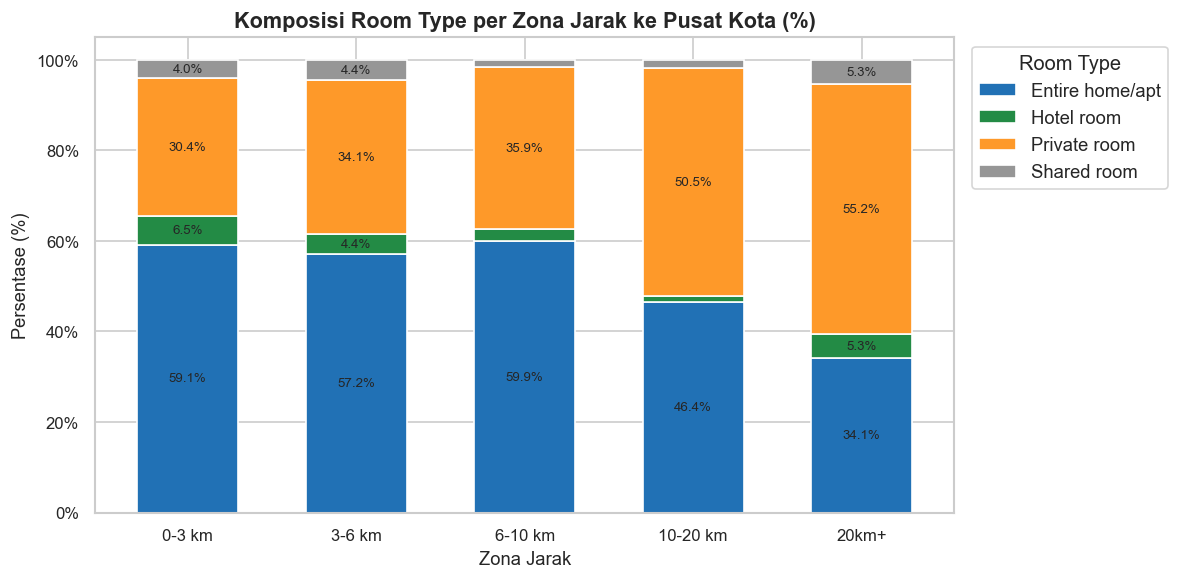


Nilai aktual (%):
room_type  Entire home/apt  Hotel room  Private room  Shared room
dist_zone                                                        
0-3 km                59.1         6.5          30.4          4.0
3-6 km                57.2         4.4          34.1          4.4
6-10 km               59.9         2.6          35.9          1.5
10-20 km              46.4         1.4          50.5          1.7
20km+                 34.1         5.3          55.2          5.3


In [55]:
rt_zone = ( 
    airbnb_eda.groupby(['dist_zone', 'room_type'], observed=True)
    .size()
    .unstack(fill_value=0)
)

rt_zone_pct = rt_zone.div(rt_zone.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
rt_zone_pct.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2171b5', '#238b45', '#fe9929', '#969696'],
    width=0.6, edgecolor='white'
)

for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 3 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

ax.set_title('Komposisi Room Type per Zona Jarak ke Pusat Kota (%)')
ax.set_ylabel('Persentase (%)')
ax.set_xlabel('Zona Jarak')
ax.set_xticklabels(rt_zone_pct.index, rotation=0)
ax.legend(title='Room Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}%'))

plt.tight_layout()
plt.show()

print('\nNilai aktual (%):')
print(rt_zone_pct.round(1).to_string())

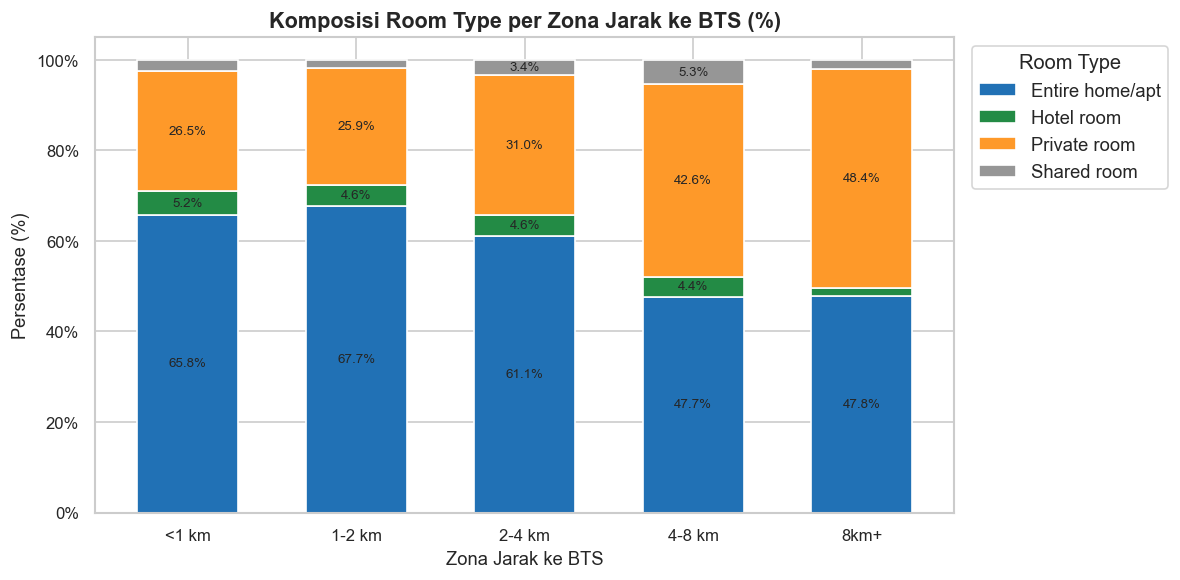


Nilai aktual (%):
room_type  Entire home/apt  Hotel room  Private room  Shared room
bts_zone                                                         
<1 km                 65.8         5.2          26.5          2.5
1-2 km                67.7         4.6          25.9          1.8
2-4 km                61.1         4.6          31.0          3.4
4-8 km                47.7         4.4          42.6          5.3
8km+                  47.8         1.9          48.4          1.9


In [56]:
# Grouping
rt_bts = ( 
    airbnb_eda.groupby(['bts_zone', 'room_type'], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Konversi ke persentase
rt_bts_pct = rt_bts.div(rt_bts.sum(axis=1), axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
rt_bts_pct.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2171b5', '#238b45', '#fe9929', '#969696'],
    width=0.6, edgecolor='white'
)

# Tambahkan label
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 3 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

# Styling
ax.set_title('Komposisi Room Type per Zona Jarak ke BTS (%)')
ax.set_ylabel('Persentase (%)')
ax.set_xlabel('Zona Jarak ke BTS')
ax.set_xticklabels(rt_bts_pct.index, rotation=0)
ax.legend(title='Room Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}%'))

plt.tight_layout()
plt.show()

# Print nilai
print('\nNilai aktual (%):')
print(rt_bts_pct.round(1).to_string())

### 3.8 Scatter Plot - Jarak vs Harga & Review

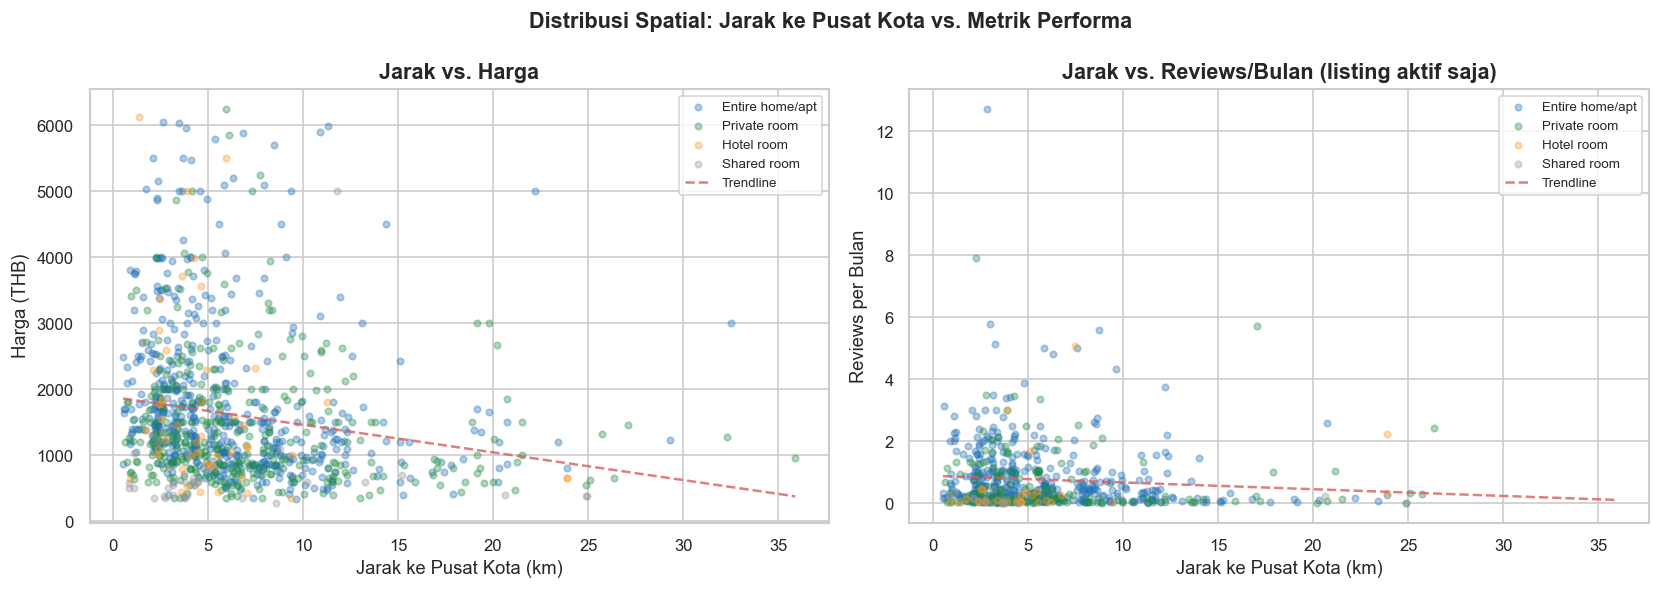

In [57]:
# Sample 1000 titik untuk performa
airbnb_eda_sample = airbnb_eda[airbnb_eda['price'] < airbnb_eda['price'].quantile(0.95)].sample(1000, random_state=42)

room_colors = {
    'Entire home/apt': '#2171b5',
    'Private room'   : '#238b45',
    'Hotel room'     : '#fe9929',
    'Shared room'    : '#969696',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Spatial: Jarak ke Pusat Kota vs. Metrik Performa', fontsize=13, fontweight='bold')

# Scatter: Jarak vs Harga
ax = axes[0]
for rtype, color in room_colors.items():
    subset = airbnb_eda_sample[airbnb_eda_sample['room_type'] == rtype]
    ax.scatter(subset['dist_center_km'], subset['price'], c=color, alpha=0.35, s=15, label=rtype)
ax.set_xlabel('Jarak ke Pusat Kota (km)')
ax.set_ylabel('Harga (THB)')
ax.set_title('Jarak vs. Harga')
ax.legend(fontsize=8, markerscale=1.5)

# Tambahkan trendline
z = np.polyfit(airbnb_eda_sample['dist_center_km'], airbnb_eda_sample['price'], 1)
p = np.poly1d(z)
x_line = np.linspace(airbnb_eda_sample['dist_center_km'].min(), airbnb_eda_sample['dist_center_km'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, alpha=0.8, label='Trendline')
ax.legend(fontsize=8)

# Scatter: Jarak vs Reviews/bulan
ax = axes[1]
airbnb_eda_sample_rev = airbnb_eda_sample[airbnb_eda_sample['reviews_per_month'] > 0]
for rtype, color in room_colors.items():
    subset = airbnb_eda_sample_rev[airbnb_eda_sample_rev['room_type'] == rtype]
    ax.scatter(subset['dist_center_km'], subset['reviews_per_month'], c=color, alpha=0.35, s=15, label=rtype)
ax.set_xlabel('Jarak ke Pusat Kota (km)')
ax.set_ylabel('Reviews per Bulan')
ax.set_title('Jarak vs. Reviews/Bulan (listing aktif saja)')
z2 = np.polyfit(airbnb_eda_sample_rev['dist_center_km'], airbnb_eda_sample_rev['reviews_per_month'], 1)
p2 = np.poly1d(z2)
ax.plot(x_line, p2(x_line), 'r--', linewidth=1.5, alpha=0.8, label='Trendline')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.9 Pengaruh Destinasi Wisata & Bandara

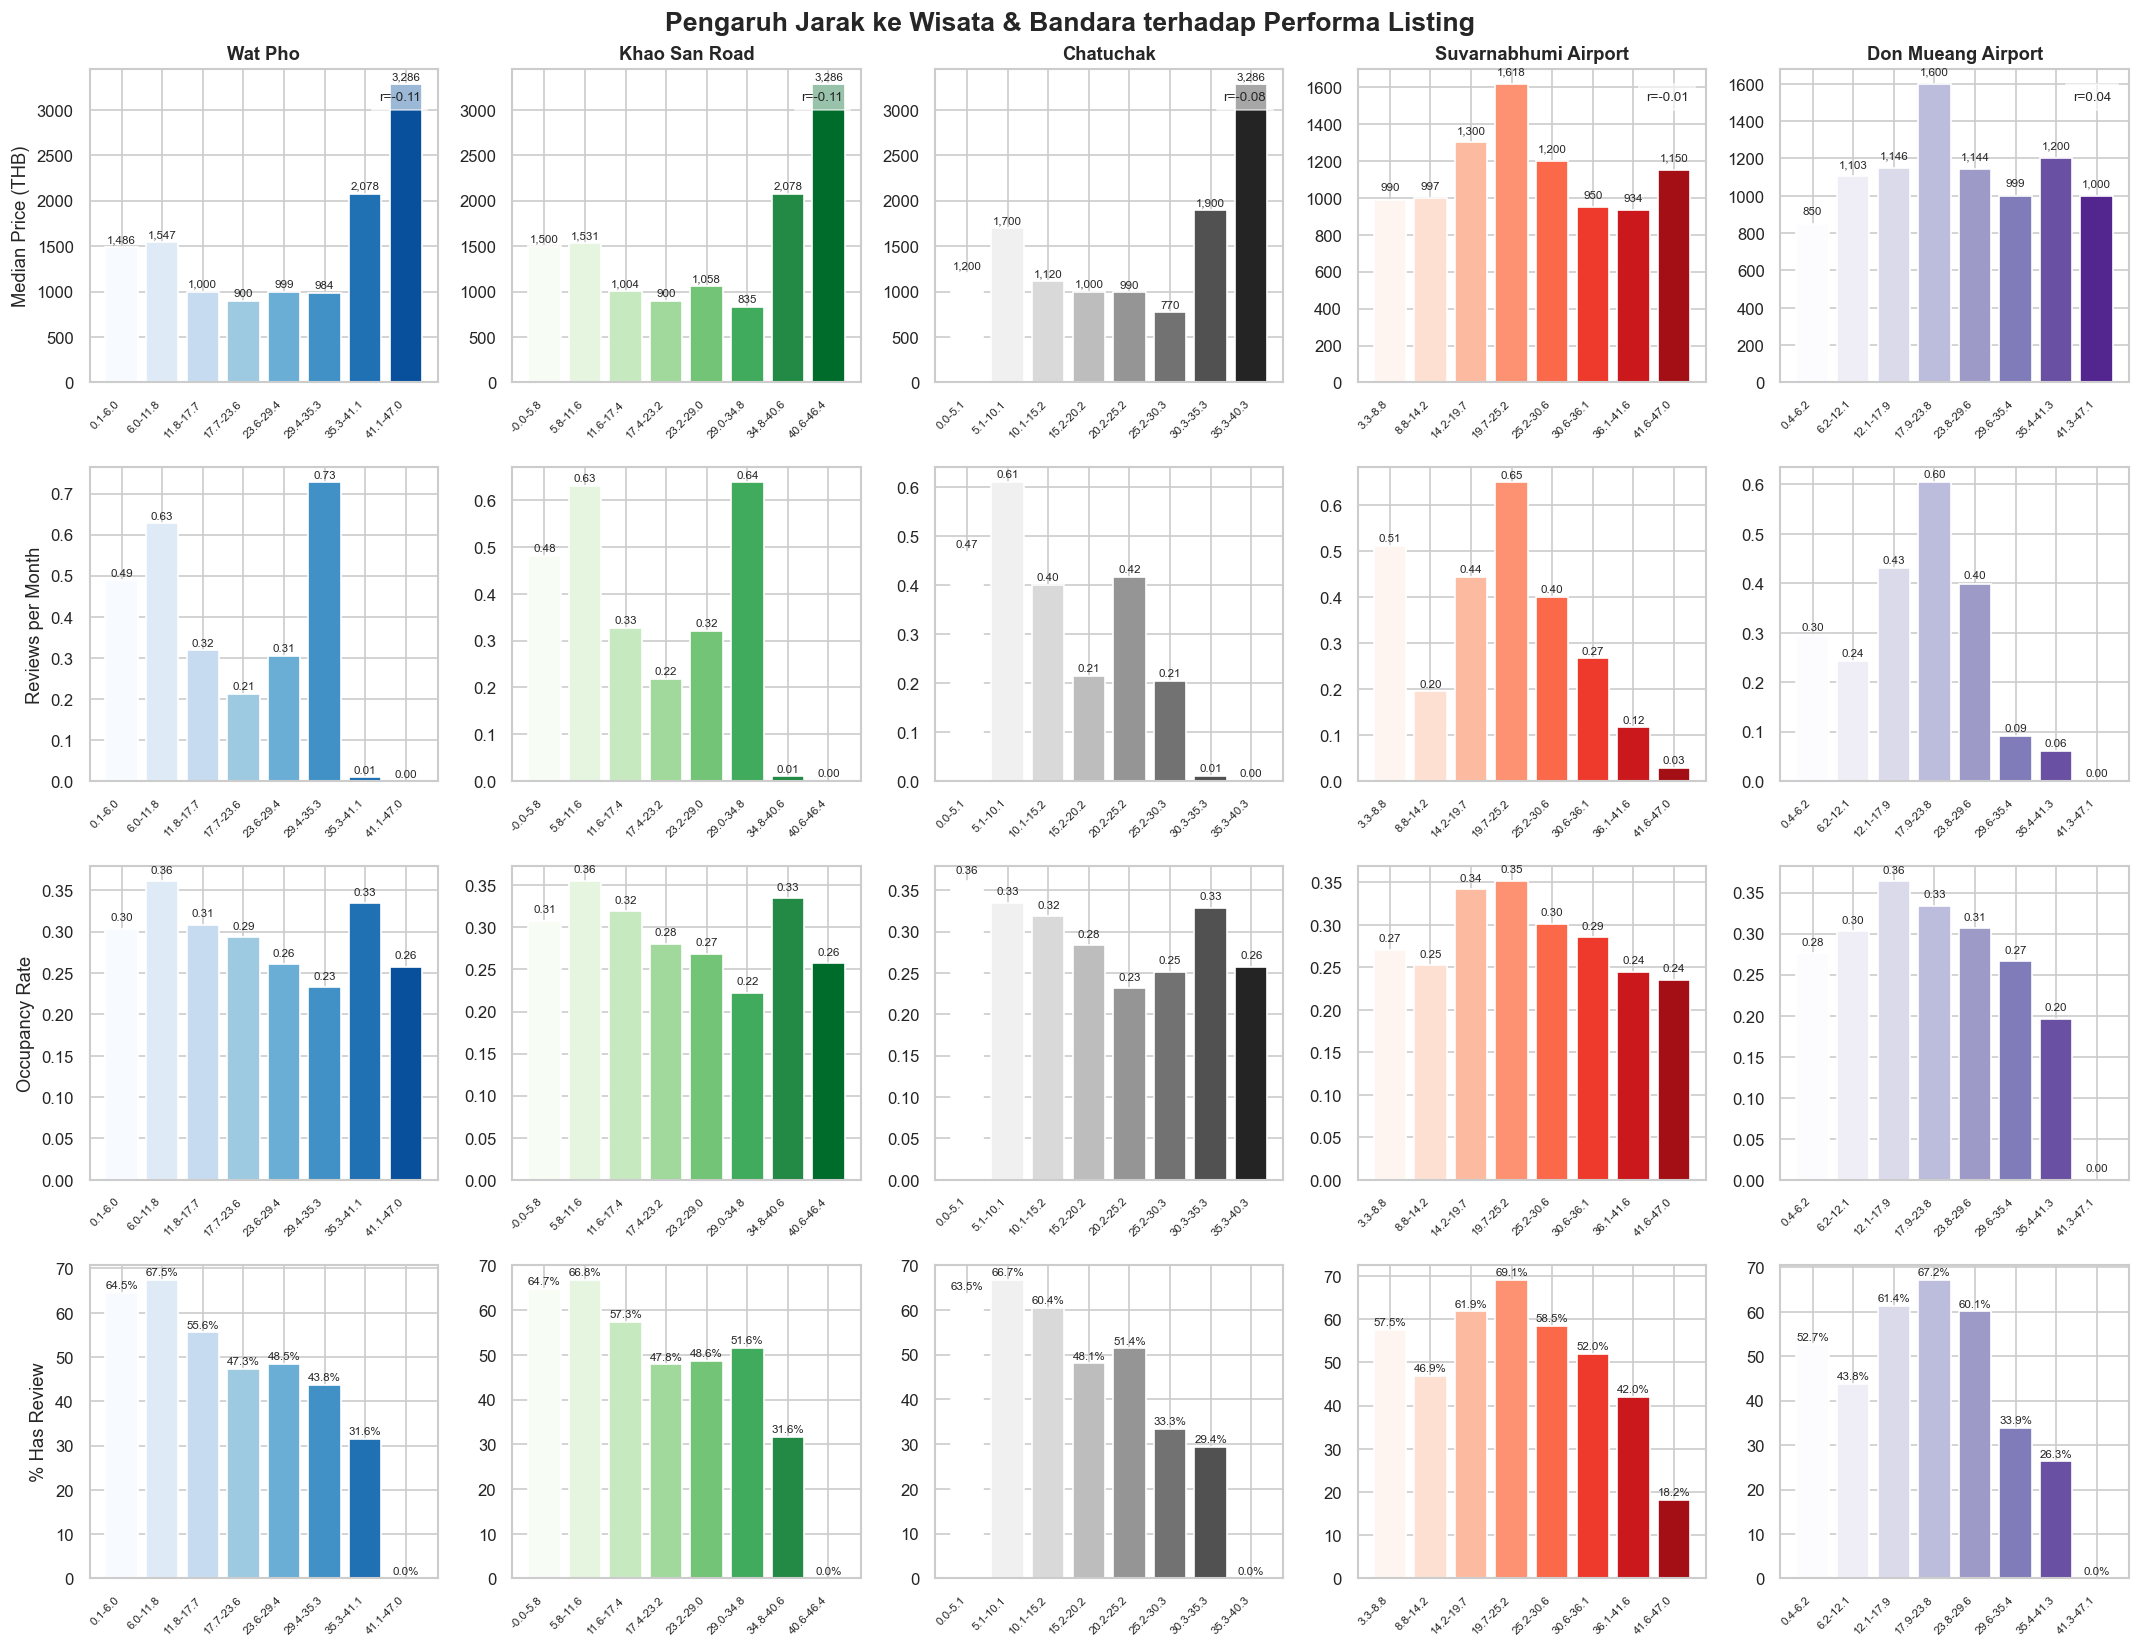

In [72]:
# ======================
# Setup
# ======================
wisata_cols = [
    ('dist_wat_pho_km',        'Wat Pho'),
    ('dist_khao_san_road_km',  'Khao San Road'),
    ('dist_chatuchak_market_km','Chatuchak'),
    ('dist_suvarnabhumi_apt_km','Suvarnabhumi Airport'),
    ('dist_don_mueang_apt_km', 'Don Mueang Airport'),
]

metrics = [
    ('price_capped', 'Median Price (THB)', 'median'),
    ('reviews_per_month', 'Reviews per Month', 'mean'),
    ('occupancy_rate', 'Occupancy Rate', 'mean'),
    ('has_review', '% Has Review', 'mean')
]

# Base colors (tiap destinasi beda tone)
base_colors = ['Blues', 'Greens', 'Greys', 'Reds', 'Purples']

fig, axes = plt.subplots(len(metrics), len(wisata_cols), figsize=(18, 14))
fig.suptitle('Pengaruh Jarak ke Wisata & Bandara terhadap Performa Listing', fontsize=16, fontweight='bold')

# ======================
# Loop
# ======================
for col_idx, (col, label) in enumerate(wisata_cols):
    
    bins = pd.cut(airbnb_eda[col], bins=8)
    
    for row_idx, (metric, metric_label, agg_type) in enumerate(metrics):
        
        ax = axes[row_idx, col_idx]
        
        # Aggregation
        if agg_type == 'median':
            zone_val = airbnb_eda.groupby(bins, observed=False)[metric].median()
        else:
            zone_val = airbnb_eda.groupby(bins, observed=False)[metric].mean()
        
        # Special handling %
        if metric == 'has_review':
            zone_val = zone_val * 100
        
        # Labels
        bin_labels = [f'{iv.left:.1f}-{iv.right:.1f}' for iv in zone_val.index]
        
        # Color grading
        cmap = plt.get_cmap(base_colors[col_idx])
        colors = [cmap(i / len(zone_val)) for i in range(len(zone_val))]
        
        bars = ax.bar(range(len(zone_val)), zone_val.values, color=colors)
        
        ax.set_xticks(range(len(zone_val)))
        ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=7)
        
        if col_idx == 0:
            ax.set_ylabel(metric_label)
        
        if row_idx == 0:
            ax.set_title(label, fontsize=11)
        
        # Annotasi
        for bar, val in zip(bars, zone_val.values):
            if metric == 'price_capped':
                txt = f'{int(val):,}'
                offset = 50
            elif metric == 'has_review':
                txt = f'{val:.1f}%'
                offset = 1
            else:
                txt = f'{val:.2f}'
                offset = 0.01
            
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + offset,
                    txt,
                    ha='center',
                    fontsize=7)
        
        # Correlation (hanya untuk price biar tidak terlalu crowded)
        if metric == 'price_capped':
            corr_val = airbnb_eda[col].corr(airbnb_eda['price_capped'])
            ax.text(0.95, 0.9, f'r={corr_val:.2f}',
                    transform=ax.transAxes,
                    ha='right',
                    fontsize=8,
                    bbox=dict(facecolor='white', alpha=0.6))

plt.tight_layout()
plt.show()

### 3.10 Ringkasan Temuan (Key Insights)

In [ ]:
print('=' * 60)
print('RINGKASAN TEMUAN — SPATIAL & LOCATION ANALYSIS')
print('=' * 60)

# 1. Gradien harga per zona
print('\n[1] GRADIEN HARGA — JARAK KE PUSAT KOTA')
for zone, row in zone_agg.iterrows():
    print(f'  {zone:>10}: median ฿{int(row["median_price"]):>5,} | rpm {row["mean_rpm"]:.2f} | has_review {row["pct_has_review"]:.1f}%')

# 2. BTS premium
print('\n[2] PREMIUM AKSES BTS')
for zone, row in bts_agg.iterrows():
    print(f'  {zone:>8}: mean ฿{int(row["mean_price"]):>5,} | rpm {row["mean_rpm"]:.2f}')
print(f'  → BTS <1km vs 8km+: {bts_agg["median_price"].iloc[0]/bts_agg["median_price"].iloc[-1]:.1f}x premium harga')
print(f'  → BTS <1km vs 8km+: {bts_agg["mean_rpm"].iloc[0]/bts_agg["mean_rpm"].iloc[-1]:.1f}x lebih sering dipesan')

# 3. Korelasi terkuat
print('\n[3] KORELASI TERKUAT DENGAN PRICE')
corr_price = airbnb_eda[spatial_cols + ['price_capped']].corr(method='spearman')['price_capped'].drop('price_capped').sort_values()
for feat, val in corr_price.items():
    bar = '█' * int(abs(val) * 40)
    direction = '-' if val < 0 else '+'
    print(f'  {feat:35s}: {direction}{abs(val):.3f} {bar}')

print('\n[4] DESTINASI WISATA')
print('  Bandara (Suvarnabhumi/Don Mueang) hampir tidak berpengaruh (r ≈ 0.0)')
print('  Wisata sejarah (Wat Pho, Khao San): r ≈ -0.10 ke -0.11 (lemah-moderat)')
print('  BTS proximity adalah prediktor spatial terkuat dalam dataset ini.')

print('\n' + '=' * 60)

RINGKASAN TEMUAN — SPATIAL & LOCATION ANALYSIS

[1] GRADIEN HARGA — JARAK KE PUSAT KOTA
      0-3 km: median ฿1,879 | rpm 0.70 | has_review 72.0%
      3-6 km: median ฿1,500 | rpm 0.58 | has_review 66.0%
     6-10 km: median ฿1,100 | rpm 0.42 | has_review 60.0%
    10-20 km: median ฿  990 | rpm 0.22 | has_review 49.0%
       20km+: median ฿  990 | rpm 0.37 | has_review 49.0%

[2] PREMIUM AKSES BTS
     <1 km: mean ฿2,846 | rpm 0.90
    1-2 km: mean ฿2,323 | rpm 0.66
    2-4 km: mean ฿2,124 | rpm 0.55
    4-8 km: mean ฿1,643 | rpm 0.43
      8km+: mean ฿1,498 | rpm 0.27
  → BTS <1km vs 8km+: 2.3x premium harga
  → BTS <1km vs 8km+: 3.4x lebih sering dipesan

[3] KORELASI TERKUAT DENGAN PRICE
  dist_nearest_bts_km                : -0.362 ██████████████
  dist_asok_bts_km                   : -0.354 ██████████████
  dist_silom_bts_km                  : -0.306 ████████████
  dist_center_km                     : -0.301 ████████████
  dist_wat_pho_km                    : -0.152 ██████
  dist_

## Summary

### Conclusion
1. **Lokasi sangat menentukan harga & performa**
    - Semakin dekat ke pusat kota --> harga median lebih tinggi dan frekuensi booking (reviews/month) lebih tinggi
    - Ada gradien jelas: pusat kota = premium, pinggiran = lebih murah & demand lebih rendah
1. **Akses transportasi (BTS) = faktor paling kuat**
    - Properti <1 km dari BTS:
        - Harga bisa berkali lipat lebih tinggi
        - Lebih sering dipesan
    - BTS proximity = prediktor spatial paling kuat terhadap harga & demand
1. **Korelasi kedekatan ke bandara dan tempat wisata tidak terlalu kuat**
    - Bandara: hampir tidak berpengaruh
    - Wisata (Wat Pho, Khao San): hanya korelasi lemah–moderat
        - Artinya: wisata ≠ driver utama, mobilitas (transport) lebih penting
1. **Review & aktivitas listing**
    - Listing dengan review:
        - Lebih “hidup” --> indikasi demand
    - Listing tanpa review:
        - Potensi underperform / baru / tidak kompetitif



### Recommendation
1. **Host (Pemilik Properti)**
    1. Prioritaskan lokasi dekat BTS
        - Jika sudah dekat --> gunakan sebagai selling point utama
        - Jika tidak --> kompensasi dengan harga atau fasilitas
    1. Strategi pricing berbasis lokasi
        - Menetapkan harga di atas median pasar untuk listing di zona <1 km
        - Menonjolkan value/experience (ruang lebih luas, fasilitas tambahan, desain, view, dll) untuk listing >4 km alih-alih bersaing harga dengan zona pusat
    1. Optimasi listing
        - Mencantumkan jarak atau waktu tempuh actual ke BTS terdekat
        - Gunakan diskon early booking atau promo first guest untuk listing yang jauh dari pusat kota dan BTS
    1. Segmentasi pasar
        - Short stay (1–7 hari) --> wisatawan
        - Long stay --> pekerja remote / ekspatriat

1. **Guest/Customer (Traveler/Tourist/Digital Nomads)**
    1. Pilih dekat BTS --> hemat waktu & biaya transport
    1. Jangan hanya fokus ke tempat wisata
    1. Pertimbangkan:
        - harga vs akses transport (trade-off utama)

1. **Airbnb (Platform)**
    1. Ranking algorithm berbasis BTS proximity
        - Boost listing dekat transportasi publik
    1. Tambah fitur product
        - Mengintegrasikan skor konektivitas transportasi (BTS, MRT, bus) sebagai filter pencarian resmi
        - Meningkatkan relevansi hasil dan membantu wisatawan yang memprioritaskan mobilitas
    1. Smart pricing recommendation (Host tools)
        - Mengembangkan pricing assistant yang membandingkan harga listing baru dengan median zona spasialnya (0–2 km, 2–5 km, dll.) dan akses BTS
        - Memberikan rekomendasi harga optimal
    1. Highlight “transport convenience”
        - Tambahkan label:
            - “Near BTS”
            - “Easy commute”
    1. Aktivasi listing pasif
        - Target listing tanpa review:
            - campaign onboarding
            - insentif first booking

1. **Investor/Developer**
    1. Fokus investasi dekat BTS
        - Faktor paling impactful
    1. Strategi yield:
        - Pusat kota --> capital gain + high nightly rate
        - Pinggiran --> occupancy play
    1. Diversifikasi:
        - Short stay + long stay portfolio